In [1]:
import os
import random
from pathlib import Path
from collections import Counter

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist, pdist
from scipy.stats import fisher_exact
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.MolStandardize import rdMolStandardize

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -----------------------------
# Paths
# -----------------------------

BASE_GENERATION_DIR = Path(
    "../../data/generated_molecules/extra900"
)

DATASET_PATH = Path(
    "../../data/figures_source_data/chembl_compound_species_activity_datapoints.csv"
)

MAB_ACTIVITY_PATH = Path(
    "../../data/figures_source_data/mycobacteroidesabscessus_chembl_data.csv"
)

LATENT_SMILES_PATH = Path(
    "../../data/figures_source_data/fig4"
    "get_latents_final_dataset_20260212-143849_ckpt_17730.csv"
) # Latents are obtained by passing the SMILES through the hVAE encoder (example in the src/LDMol folder)

LATENT_ARRAY_PATH = Path(
    "../../data/figures_source_data/fig4"
    "get_latents_final_dataset_20260212-143849_ckpt_17730_latents.npy"
) # Latents are obtained by passing the SMILES through the hVAE encoder (example in the src/LDMol folder)

MAB_LATENT_SMILES_PATH = Path(
    "../../data/figures_source_data/fig4"
    "get_latents_mabscessus_20260215-170221_ckpt_17730.csv"
) # Latents are obtained by passing the SMILES through the hVAE encoder (example in the src/LDMol folder)

MAB_LATENT_ARRAY_PATH = Path(
    "../../data/figures_source_data/fig4"
    "get_latents_mabscessus_20260215-170221_ckpt_17730_latents.npy"
) # Latents are obtained by passing the SMILES through the hVAE encoder (example in the src/LDMol folder)

BACTERIAL_EMBEDDINGS_PATH = Path(
    "../../data/bacteria_embeddings.h5"
)

OUTDIR = BASE_GENERATION_DIR / "mycobacteroidesabscessus" / "mabs_final_figure"
OUTDIR.mkdir(parents=True, exist_ok=True)

TARGET_BUG = "mycobacteroidesabscessus"
TARGET_GEN_FOLDER = "mycobacteroidesabscessus"

K_VALUES = [1, 2, 5, 10, 20]
N_BOOT = 100

In [2]:
def standardize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        mol = rdMolStandardize.Cleanup(mol)
        mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
        mol = rdMolStandardize.Uncharger().uncharge(mol)
        mol = rdMolStandardize.TautomerEnumerator().Canonicalize(mol)
        Chem.SanitizeMol(mol)
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return None


def smiles_to_fp(smiles, radius=2, n_bits=2048):
    smi = standardize_smiles(smiles)
    if smi is None:
        return None
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)


def tanimoto_distance_matrix(fps_a, fps_b):
    """
    Returns distance = 1 - Tanimoto similarity.
    """
    dists = np.zeros((len(fps_a), len(fps_b)), dtype=float)

    for i, fp in enumerate(fps_a):
        sims = DataStructs.BulkTanimotoSimilarity(fp, fps_b)
        dists[i, :] = 1 - np.asarray(sims)

    return dists


def closest_tanimoto_to_set(query_fps, ref_fps):
    """
    For each query molecule, return closest/max Tanimoto similarity to ref set.
    """
    closest = []

    for fp in query_fps:
        sims = DataStructs.BulkTanimotoSimilarity(fp, ref_fps)
        closest.append(np.max(sims))

    return np.asarray(closest)


def p_to_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

In [3]:
# Load bacterial embeddings and species distances
with h5py.File(BACTERIAL_EMBEDDINGS_PATH, "r") as f:
    bug_embeddings = f["embeddings"][:]
    bug_species = f["species"][:]

bug_species = [s.decode("utf8").lower().replace(' ','') if isinstance(s, bytes) else str(s) for s in bug_species]

bug_emb_cols = [f"bug_emb_{i}" for i in range(bug_embeddings.shape[1])]

bacterial_df = pd.DataFrame(bug_embeddings, columns=bug_emb_cols)
bacterial_df.insert(0, "species", bug_species)

if TARGET_BUG not in set(bacterial_df["species"]):
    raise ValueError(f"{TARGET_BUG} not found in bacterial embeddings")

target_idx = np.where(bacterial_df["species"].values == TARGET_BUG)[0][0]
target_vec = bacterial_df.loc[[target_idx], bug_emb_cols].values
all_bug_vecs = bacterial_df[bug_emb_cols].values

distance_to_mabs = cdist(target_vec, all_bug_vecs, metric="cosine").ravel()
similarity_to_mabs = 1 - distance_to_mabs

species_similarity = pd.DataFrame({
    "bug_species": bacterial_df["species"].values,
    "distance_to_mabs": distance_to_mabs,
    "similarity_to_mabs": similarity_to_mabs,
})

species_similarity = (
    species_similarity
    .sort_values("distance_to_mabs")
    .reset_index(drop=True)
)

species_similarity["rank_to_mabs"] = np.arange(1, len(species_similarity) + 1)

species_similarity.head(10)

,bug_species,distance_to_mabs,similarity_to_mabs,rank_to_mabs
0,mycobacteroidesabscessus,2.220446e-16,1.000000,1
1,nocardiaabscessus,1.479526e-01,0.852047,2
2,mycolicibacteriummucogenicum,2.736693e-01,0.726331,3
3,mycobacteriumulcerans,2.980736e-01,0.701926,4
4,mycolicibacternonchromogenicus,3.031196e-01,0.696880,5
5,mycolicibacteriumaubagnense,3.081405e-01,0.691859,6
6,mycolicibacteriumflavescens,3.100703e-01,0.689930,7
7,mycobacteriummarseillense,3.153764e-01,0.684624,8
8,mycolicibacteriumgoodii,3.176926e-01,0.682307,9
9,mycobacteriumavium,3.213272e-01,0.678673,10


In [4]:
# Load active compound-species pairs and latent lookup
# Main ChEMBL-like activity table
data = pd.read_csv(DATASET_PATH)

active_pairs = data.loc[data["active"] == 1, ["smiles", "species"]].copy()

# Extra M. abscessus activity table
mab_data = pd.read_csv(MAB_ACTIVITY_PATH)
mab_active_pairs = mab_data.loc[mab_data["active"] == 1, ["smiles"]].copy()
mab_active_pairs["species"] = TARGET_GEN_FOLDER

active_pairs = pd.concat([active_pairs, mab_active_pairs], ignore_index=True)
active_pairs = active_pairs.drop_duplicates(["smiles", "species"]).reset_index(drop=True)

print("Active compound-species pairs:", active_pairs.shape)
active_pairs.head()

Active compound-species pairs: (107971, 2)


,smiles,species
0,COc1cc2c(cc1OCCCC(=O)Nc1cc(C(=O)Nc3ccc4oc(C(=O...,acinetobacterbaylyi
1,COc1cc2c(cc1OCCCC(=O)Nc1cc(C(=O)Nc3ccc4sc(C(=O...,acinetobacterbaylyi
2,C=CCO/N=C1\CN(c2c(F)cc3c(=O)c(C(=O)O)cn(C4CC4)...,acinetobactercalcoaceticus
3,CC(=O)N/C=C/SC1=C(C(=O)O)N2C(=O)C(C(C)O)[C@H]2C1,acinetobactercalcoaceticus
4,CC(=O)N/C=C/[S+]([O-])C1=C(C(=O)O)N2C(=O)C(C(C...,acinetobactercalcoaceticus


In [5]:
active_pairs['species'].nunique()

274

In [6]:
# Load latent lookup for known compounds
smiles_main = pd.read_csv(LATENT_SMILES_PATH)["smiles"].values
latents_main = np.load(LATENT_ARRAY_PATH)

smiles_mab = pd.read_csv(MAB_LATENT_SMILES_PATH)["smiles"].values
latents_mab = np.load(MAB_LATENT_ARRAY_PATH)

latents_dict = dict(zip(smiles_main, latents_main))
latents_dict.update(dict(zip(smiles_mab, latents_mab)))

print("Latent lookup size:", len(latents_dict))

Latent lookup size: 179348


In [7]:
# Build active_meta and active_latents
active_rows = []
active_latents = []
missing_latents = 0

for row in active_pairs.itertuples(index=False):
    smi = row.smiles
    sp = row.species

    if smi not in latents_dict:
        missing_latents += 1
        continue

    active_rows.append({
        "active_smiles": smi,
        "active_species": sp,
    })
    active_latents.append(latents_dict[smi])

active_meta = pd.DataFrame(active_rows)
active_latents = np.asarray(active_latents)

active_meta["active_pair_id"] = np.arange(len(active_meta))

print("Active pairs with latents:", active_meta.shape)
print("Active latent matrix:", active_latents.shape)
print("Missing active-pair latents:", missing_latents)

Active pairs with latents: (93753, 3)
Active latent matrix: (93753, 300)
Missing active-pair latents: 14218


In [8]:
active_meta

,active_smiles,active_species,active_pair_id
0,COc1cc2c(cc1OCCCC(=O)Nc1cc(C(=O)Nc3ccc4oc(C(=O...,acinetobacterbaylyi,0
1,COc1cc2c(cc1OCCCC(=O)Nc1cc(C(=O)Nc3ccc4sc(C(=O...,acinetobacterbaylyi,1
2,C=CCO/N=C1\CN(c2c(F)cc3c(=O)c(C(=O)O)cn(C4CC4)...,acinetobactercalcoaceticus,2
3,CC(=O)N/C=C/SC1=C(C(=O)O)N2C(=O)C(C(C)O)[C@H]2C1,acinetobactercalcoaceticus,3
4,CC(=O)N/C=C/[S+]([O-])C1=C(C(=O)O)N2C(=O)C(C(C...,acinetobactercalcoaceticus,4
...,...,...,...
93748,O=C(NC1CCCCCCC1)c1cc2cc(Cl)ccc2o1,mycobacteroidesabscessus,93748
93749,O=C(NCC12CC3CC(CC(C3)C1)C2)c1cc2ccccc2[nH]1,mycobacteroidesabscessus,93749
93750,O=C(Nc1nc2ccc(C(F)(F)F)cc2s1)C1CCCC(C(F)(F)F)C1,mycobacteroidesabscessus,93750
93751,O=C(Nc1nc2ccc(C(F)(F)F)cc2s1)C1CCCC2(CC2)C1,mycobacteroidesabscessus,93751


In [9]:
# Count active compound-species pairs per bacterial species.
# Important: this is pair-based, so a molecule active against 3 species contributes 3 rows.
active_species_counts = (
    active_meta
    .dropna(subset=["active_species"])
    .groupby("active_species")
    .size()
    .rename("n_active_pairs")
    .reset_index()
)

active_supported_species_similarity = (
    species_similarity
    .merge(
        active_species_counts,
        left_on="bug_species",
        right_on="active_species",
        how="inner",
    )
    .drop(columns=["active_species"])
)

active_supported_species_similarity = active_supported_species_similarity[
    active_supported_species_similarity["bug_species"] != TARGET_BUG
].copy()

active_supported_species_similarity = (
    active_supported_species_similarity
    .sort_values("distance_to_mabs")
    .reset_index(drop=True)
)

active_supported_species_similarity.head(20)

,bug_species,distance_to_mabs,similarity_to_mabs,rank_to_mabs,n_active_pairs
0,mycobacteriumulcerans,0.298074,0.701926,4,14
1,mycobacteriumavium,0.321327,0.678673,10,562
2,mycobacteriumtuberculosis,0.334259,0.665741,22,14947
3,mycobacteriumscrofulaceum,0.341816,0.658184,27,6
4,mycobacteriumgordonae,0.353369,0.646631,33,14
5,mycobacteriummarinum,0.354882,0.645118,36,35
6,mycobacteriumintracellulare,0.357769,0.642231,40,129
7,mycobacteriumszulgai,0.364866,0.635134,43,1
8,mycobacteriummalmoense,0.365911,0.634089,44,2
9,nocardiacyriacigeorgica,0.370148,0.629852,46,1


In [10]:
# All vs. all distances within active species
indexes_active_species = np.isin(bug_species, active_supported_species_similarity["bug_species"].values)
distances_all_vs_all = pdist(all_bug_vecs[indexes_active_species], metric="cosine")

# A. Distance distribution: all vs all bacteria in training vs M. abscessus vs all in training

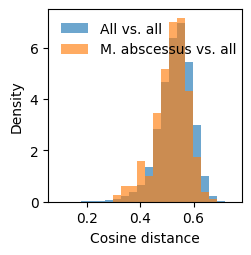

In [11]:
fig, axA = plt.subplots(figsize=(2.5, 2.5))
# -----------------------------
# Plot A
# -----------------------------
bin_width = 0.03

x_all = distances_all_vs_all
x_ma = active_supported_species_similarity['distance_to_mabs'].values

x_min = min(x_all.min(), x_ma.min())
x_max = max(x_all.max(), x_ma.max())

bins = np.arange(x_min, x_max + bin_width, bin_width)

axA.hist(
    x_all,
    bins=bins,
    alpha=0.65,
    label="All vs. all",
    density=True,
)

axA.hist(
    x_ma,
    bins=bins,
    alpha=0.65,
    label="M. abscessus vs. all",
    density=True,
)

axA.set_xlabel("Cosine distance")
axA.set_ylabel("Density")
axA.legend(frameon=False, loc="upper left")
# clean_ax(axA)
plt.show()

# B. Proportion of gen molecules with at least 1 NN from the related species (k=[1-20])

In [12]:
top3_all_bacteria = (
    species_similarity
    .query("bug_species != @TARGET_BUG")
    .sort_values("distance_to_mabs")
    .head(3)
)

top3_active_supported = (
    active_supported_species_similarity
    .sort_values("distance_to_mabs")
    .head(3)
)

print("Top 3 closest bacteria to M. abscessus, all bacterial descriptors:")
display(top3_all_bacteria[["bug_species", "distance_to_mabs", "similarity_to_mabs"]])

print("Top 3 closest bacteria to M. abscessus with active molecules:")
display(top3_active_supported[["bug_species", "distance_to_mabs", "similarity_to_mabs", "n_active_pairs"]])

Top 3 closest bacteria to M. abscessus, all bacterial descriptors:


,bug_species,distance_to_mabs,similarity_to_mabs
1,nocardiaabscessus,0.147953,0.852047
2,mycolicibacteriummucogenicum,0.273669,0.726331
3,mycobacteriumulcerans,0.298074,0.701926


Top 3 closest bacteria to M. abscessus with active molecules:


,bug_species,distance_to_mabs,similarity_to_mabs,n_active_pairs
0,mycobacteriumulcerans,0.298074,0.701926,14
1,mycobacteriumavium,0.321327,0.678673,562
2,mycobacteriumtuberculosis,0.334259,0.665741,14947


In [13]:
RELATED_TOP3_SPECIES = top3_active_supported["bug_species"].tolist()

print("Using these active-supported top-3 related species:")
RELATED_TOP3_SPECIES

Using these active-supported top-3 related species:


['mycobacteriumulcerans', 'mycobacteriumavium', 'mycobacteriumtuberculosis']

In [14]:
# Load generated molecules
def generated_latents_path(species_folder):
    return (
        BASE_GENERATION_DIR
        / species_folder
        / "CfgScale_035_SamplingSteps_0100"
        / "generated_latents.npy"
    )


def decoded_smiles_path(species_folder):
    return (
        BASE_GENERATION_DIR
        / species_folder
        / "CfgScale_035_SamplingSteps_0100"
        / "decoded_molecules"
        / "generated_latents.npy_decoded_latents.csv"
    )


def has_generation_files(species_folder):
    return generated_latents_path(species_folder).exists() and decoded_smiles_path(species_folder).exists()


def load_generated_for_species(species_folder):
    latents = np.load(generated_latents_path(species_folder))
    decoded = pd.read_csv(decoded_smiles_path(species_folder))

    mask = decoded["decoded_smiles"].notna().values

    latents = latents[mask]
    decoded = decoded.loc[mask].reset_index(drop=True)

    meta = pd.DataFrame({
        "generated_id": [f"{species_folder}__{i}" for i in range(len(decoded))],
        "species_generated_for": species_folder,
        "smiles": decoded["decoded_smiles"].values,
        "local_generated_index": np.arange(len(decoded)),
    })

    if "batch_number" in decoded.columns:
        meta["batch_number"] = decoded["batch_number"].values

    return meta, latents


available_generation_folders = sorted([
    p.name for p in BASE_GENERATION_DIR.iterdir()
    if p.is_dir() and has_generation_files(p.name)
])

print("Available generation folders:", len(available_generation_folders))
available_generation_folders[:20]

Available generation folders: 274


['acinetobacterbaumannii',
 'acinetobacterbaylyi',
 'acinetobactercalcoaceticus',
 'acinetobactercalcoaceticussubsp.anitratus',
 'acinetobacterhaemolyticus',
 'acinetobacterlwoffii',
 'acinetobacterpittii',
 'actinomycesisraelii',
 'actinomycesnaeslundii',
 'actinomycesviscosus',
 'aeromonascaviae',
 'aeromonashydrophila',
 'aeromonassalmonicida',
 'aeromonassobria',
 'aggregatibacteractinomycetemcomitans',
 'agrobacteriumtumefaciens',
 'alcaligenesfaecalis',
 'aliivibriofischeri',
 'anaerococcusprevotii',
 'anaerococcustetradius']

In [15]:
# M. abscessus generated molecules
mab_meta, mab_latents = load_generated_for_species(TARGET_GEN_FOLDER)
mab_meta["query_group"] = "mabs_generated"

print("M. abscessus generated:", mab_meta.shape, mab_latents.shape)

M. abscessus generated: (900, 6) (900, 300)


In [16]:
# Related generated molecules
related_meta_list = []
related_latents_list = []

for folder in RELATED_TOP3_SPECIES:
    if folder is None:
        continue

    meta_sp, lat_sp = load_generated_for_species(folder)
    meta_sp["query_group"] = "related_generated"
    meta_sp["related_generation_folder"] = folder

    related_meta_list.append(meta_sp)
    related_latents_list.append(lat_sp)

related_gen_meta = pd.concat(related_meta_list, ignore_index=True)
related_gen_latents = np.vstack(related_latents_list)

print("Related generated:", related_gen_meta.shape, related_gen_latents.shape)
related_gen_meta.groupby("species_generated_for").size()

Related generated: (2700, 7) (2700, 300)


species_generated_for
mycobacteriumavium           900
mycobacteriumtuberculosis    900
mycobacteriumulcerans        900
dtype: int64

In [17]:
related_or_target_folders = set([TARGET_GEN_FOLDER] + [x for x in RELATED_TOP3_SPECIES if x is not None])

unrelated_generation_folders = [
    f for f in available_generation_folders
    if f not in related_or_target_folders
]

print("Unrelated generation folders:", len(unrelated_generation_folders))
unrelated_generation_folders[:20]

Unrelated generation folders: 270


['acinetobacterbaumannii',
 'acinetobacterbaylyi',
 'acinetobactercalcoaceticus',
 'acinetobactercalcoaceticussubsp.anitratus',
 'acinetobacterhaemolyticus',
 'acinetobacterlwoffii',
 'acinetobacterpittii',
 'actinomycesisraelii',
 'actinomycesnaeslundii',
 'actinomycesviscosus',
 'aeromonascaviae',
 'aeromonashydrophila',
 'aeromonassalmonicida',
 'aeromonassobria',
 'aggregatibacteractinomycetemcomitans',
 'agrobacteriumtumefaciens',
 'alcaligenesfaecalis',
 'aliivibriofischeri',
 'anaerococcusprevotii',
 'anaerococcustetradius']

In [18]:
# Load unrelated generated pool.
# If this is too large, set MAX_UNRELATED_FOLDERS to a smaller number.
MAX_UNRELATED_FOLDERS = None  # e.g. 20 for speed

folders_to_load = unrelated_generation_folders
if MAX_UNRELATED_FOLDERS is not None:
    folders_to_load = folders_to_load[:MAX_UNRELATED_FOLDERS]

unrelated_meta_list = []
unrelated_latents_list = []

for folder in folders_to_load:
    try:
        meta_sp, lat_sp = load_generated_for_species(folder)
        meta_sp["query_group"] = "unrelated_generated_pool"
        unrelated_meta_list.append(meta_sp)
        unrelated_latents_list.append(lat_sp)
    except Exception as e:
        print(f"Skipping {folder}: {e}")

unrelated_pool_meta = pd.concat(unrelated_meta_list, ignore_index=True)
unrelated_pool_latents = np.vstack(unrelated_latents_list)

unrelated_pool_meta["unrelated_pool_index"] = np.arange(len(unrelated_pool_meta))

print("Unrelated generated pool:", unrelated_pool_meta.shape, unrelated_pool_latents.shape)

Unrelated generated pool: (242817, 7) (242817, 300)


In [19]:
unrelated_pool_meta.head(1)

,generated_id,species_generated_for,smiles,local_generated_index,batch_number,query_group,unrelated_pool_index
0,acinetobacterbaumannii__0,acinetobacterbaumannii,CN(C)C(=O)C1CC(O)C2OC(C[N+](=O)[O-])COC2C1C(=C...,0,0,unrelated_generated_pool,0


In [20]:
active_meta.head(1)

,active_smiles,active_species,active_pair_id
0,COc1cc2c(cc1OCCCC(=O)Nc1cc(C(=O)Nc3ccc4oc(C(=O...,acinetobacterbaylyi,0


In [21]:
active_latents.shape

(93753, 300)

In [22]:
# Rest of active molecules
unrelated_mask = (
    active_meta['active_smiles'].notna()
    & ~active_meta['active_species'].isin(related_or_target_folders)
)

unrelated_actives = (
    active_meta.loc[unrelated_mask]
    .copy()
    .reset_index(drop=True)
)

unrelated_active_latents = active_latents[unrelated_mask]

unrelated_actives["query_group"] = "unrelated_actives_pool"
unrelated_actives["unrelated_active_index"] = np.arange(
    len(unrelated_actives)
)

assert len(unrelated_actives) == len(unrelated_active_latents)

In [23]:
MAX_K = max(K_VALUES)

nn_active = NearestNeighbors(
    n_neighbors=MAX_K,
    metric="cosine",
    algorithm="brute",
)

nn_active.fit(active_latents)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [24]:
def get_neighbor_species_for_queries(query_meta, query_latents, query_set_name):
    """
    Finds nearest active compound-species pairs in latent space.
    Returns one row per query molecule x neighbor rank.
    """
    dists, idx = nn_active.kneighbors(query_latents, return_distance=True)

    records = []

    for i in range(query_latents.shape[0]):
        qid = query_meta.iloc[i].get("generated_id", f"{query_set_name}__{i}")

        for r in range(MAX_K):
            active_idx = idx[i, r]
            active_row = active_meta.iloc[active_idx]

            records.append({
                "query_set": query_set_name,
                "query_index": i,
                "generated_id": qid,
                "neighbor_rank": r + 1,
                "neighbor_latent_cosine_distance": dists[i, r],
                "neighbor_active_smiles": active_row["active_smiles"],
                "neighbor_active_species": active_row["active_species"],
            })

    return pd.DataFrame(records)


def molecule_level_hit_rate(neighbors_df, species_set, k_values=K_VALUES):
    """
    Fraction of query molecules with >=1 neighbor from species_set among top-k neighbors.
    """
    species_set = set(species_set)
    rows = []

    for query_set, df_set in neighbors_df.groupby("query_set"):
        for k in k_values:
            df_k = df_set[df_set["neighbor_rank"] <= k].copy()
            df_k["hit"] = df_k["neighbor_active_species"].isin(species_set)

            per_mol = (
                df_k
                .groupby("generated_id")["hit"]
                .any()
                .astype(int)
            )

            rows.append({
                "query_set": query_set,
                "k": k,
                "n_molecules": len(per_mol),
                "n_hits": int(per_mol.sum()),
                "fraction": per_mol.mean(),
            })

    return pd.DataFrame(rows)

In [25]:
# Fixed sets: M. abscessus and related generated species
neighbors_mab = get_neighbor_species_for_queries(
    mab_meta,
    mab_latents,
    query_set_name="mabs_generated",
)

mab_hits = molecule_level_hit_rate(
    neighbors_mab,
    species_set=RELATED_TOP3_SPECIES,
    k_values=K_VALUES,
)

mab_hits

,query_set,k,n_molecules,n_hits,fraction
0,mabs_generated,1,900,313,0.347778
1,mabs_generated,2,900,400,0.444444
2,mabs_generated,5,900,524,0.582222
3,mabs_generated,10,900,661,0.734444
4,mabs_generated,20,900,743,0.825556


In [26]:
neighbors_related = get_neighbor_species_for_queries(
    related_gen_meta,
    related_gen_latents,
    query_set_name="related_generated",
)

related_hits = molecule_level_hit_rate(
    neighbors_related,
    species_set=RELATED_TOP3_SPECIES,
    k_values=K_VALUES,
)

related_hits

,query_set,k,n_molecules,n_hits,fraction
0,related_generated,1,2700,1521,0.563333
1,related_generated,2,2700,1926,0.713333
2,related_generated,5,2700,2371,0.878148
3,related_generated,10,2700,2645,0.979630
4,related_generated,20,2700,2697,0.998889


In [27]:
neighbors_unrelated_actives = get_neighbor_species_for_queries(
    unrelated_actives,
    unrelated_active_latents,
    query_set_name="unrelated_actives",
)

unrelated_actives_hits = molecule_level_hit_rate(
    neighbors_unrelated_actives,
    species_set=RELATED_TOP3_SPECIES,
    k_values=K_VALUES,
)

unrelated_actives_hits

,query_set,k,n_molecules,n_hits,fraction
0,unrelated_actives,1,78044,1007,0.012903
1,unrelated_actives,2,78044,2549,0.032661
2,unrelated_actives,5,78044,5743,0.073587
3,unrelated_actives,10,78044,9769,0.125173
4,unrelated_actives,20,78044,16572,0.212342


In [28]:
# Bootstrap random unrelated generated and random active molecules
N_RANDOM_GEN = len(mab_meta)

boot_rows = []
fisher_rows = []

for rep in range(N_BOOT):
    seed = SEED + rep

    # --------------------------
    # Random unrelated generated
    # --------------------------
    sample_unrel_meta = unrelated_pool_meta.sample(
        n=N_RANDOM_GEN,
        replace=len(unrelated_pool_meta) < N_RANDOM_GEN,
        random_state=seed,
    ).copy()

    sample_unrel_latents = unrelated_pool_latents[sample_unrel_meta["unrelated_pool_index"].values]

    sample_unrel_meta = sample_unrel_meta.reset_index(drop=True)
    sample_unrel_meta["generated_id"] = [f"random_unrelated_gen_rep{rep}__{i}" for i in range(len(sample_unrel_meta))]

    neigh_unrel = get_neighbor_species_for_queries(
        sample_unrel_meta,
        sample_unrel_latents,
        query_set_name="random_unrelated_generated",
    )

    hits_unrel = molecule_level_hit_rate(
        neigh_unrel,
        species_set=RELATED_TOP3_SPECIES,
        k_values=K_VALUES,
    )
    hits_unrel["repeat"] = rep
    boot_rows.append(hits_unrel)

# --------------------------
    # Fisher: M. abscessus vs random unrelated generated
    # --------------------------
    for k in K_VALUES:
        m = mab_hits[mab_hits["k"] == k].iloc[0]
        u = hits_unrel[hits_unrel["k"] == k].iloc[0]

        table = [
            [int(m["n_hits"]), int(m["n_molecules"] - m["n_hits"])],
            [int(u["n_hits"]), int(u["n_molecules"] - u["n_hits"])],
        ]

        odds_ratio, p_value = fisher_exact(table, alternative="greater")

        fisher_rows.append({
            "repeat": rep,
            "k": k,
            "comparison": "mabs_generated_vs_random_unrelated_generated",
            "odds_ratio": odds_ratio,
            "p_value": p_value,
        })

boot_hits = pd.concat(boot_rows, ignore_index=True)
fisher_repeated = pd.DataFrame(fisher_rows)

boot_hits.head(), fisher_repeated.head()

(                    query_set   k  n_molecules  n_hits  fraction  repeat
 0  random_unrelated_generated   1          900     120  0.133333       0
 1  random_unrelated_generated   2          900     162  0.180000       0
 2  random_unrelated_generated   5          900     241  0.267778       0
 3  random_unrelated_generated  10          900     297  0.330000       0
 4  random_unrelated_generated  20          900     346  0.384444       0,
    repeat   k                                    comparison  odds_ratio  \
 0       0   1  mabs_generated_vs_random_unrelated_generated    3.465928   
 1       0   2  mabs_generated_vs_random_unrelated_generated    3.644444   
 2       0   5  mabs_generated_vs_random_unrelated_generated    3.810762   
 3       0  10  mabs_generated_vs_random_unrelated_generated    5.615190   
 4       0  20  mabs_generated_vs_random_unrelated_generated    7.577446   
 
         p_value  
 0  3.556001e-27  
 1  1.610849e-34  
 2  2.873686e-42  
 3  4.131554e-68  
 4

In [29]:
# ============================================================
# Summarise panel B
# ============================================================
boot_summary = (
    boot_hits
    .groupby(["query_set", "k"])
    .agg(
        mean_fraction=("fraction", "mean"),
        sd_fraction=("fraction", "std"),
        ci95_fraction=(
            "fraction",
            lambda x: 1.96 * x.std(ddof=1) / np.sqrt(len(x)),
        ),
        mean_n_hits=("n_hits", "mean"),
        sd_n_hits=("n_hits", "std"),
        n_repeats=("repeat", "nunique"),
    )
    .reset_index()
)

fixed_summary = pd.concat(
    [
        mab_hits,
        related_hits,
        unrelated_actives_hits,
    ],
    ignore_index=True,
)

fixed_summary = fixed_summary.rename(
    columns={"fraction": "mean_fraction"}
)

fixed_summary["sd_fraction"] = 0.0
fixed_summary["ci95_fraction"] = 0.0
fixed_summary["n_repeats"] = 1

plot_summary_b = pd.concat(
    [
        fixed_summary[
            [
                "query_set",
                "k",
                "mean_fraction",
                "sd_fraction",
                "ci95_fraction",
                "n_repeats",
            ]
        ],
        boot_summary[
            [
                "query_set",
                "k",
                "mean_fraction",
                "sd_fraction",
                "ci95_fraction",
                "n_repeats",
            ]
        ],
    ],
    ignore_index=True,
)

fisher_summary = (
    fisher_repeated
    .groupby(["comparison", "k"])
    .agg(
        median_odds_ratio=("odds_ratio", "median"),
        median_p_value=("p_value", "median"),
        min_p_value=("p_value", "min"),
        max_p_value=("p_value", "max"),
    )
    .reset_index()
)

fisher_summary["stars"] = fisher_summary[
    "median_p_value"
].apply(p_to_stars)

display(plot_summary_b)
display(fisher_summary)

,query_set,k,mean_fraction,sd_fraction,ci95_fraction,n_repeats
0,mabs_generated,1,0.347778,0.000000,0.000000,1
1,mabs_generated,2,0.444444,0.000000,0.000000,1
2,mabs_generated,5,0.582222,0.000000,0.000000,1
3,mabs_generated,10,0.734444,0.000000,0.000000,1
4,mabs_generated,20,0.825556,0.000000,0.000000,1
5,related_generated,1,0.563333,0.000000,0.000000,1
6,related_generated,2,0.713333,0.000000,0.000000,1
7,related_generated,5,0.878148,0.000000,0.000000,1
8,related_generated,10,0.979630,0.000000,0.000000,1
9,related_generated,20,0.998889,0.000000,0.000000,1


,comparison,k,median_odds_ratio,median_p_value,min_p_value,max_p_value,stars
0,mabs_generated_vs_random_unrelated_generated,1,3.336924,6.095787e-26,3.282051e-35,1.920649e-18,****
1,mabs_generated_vs_random_unrelated_generated,2,3.563636,1.397489e-33,9.418508e-43,2.000812e-24,****
2,mabs_generated_vs_random_unrelated_generated,5,3.854313,6.975691e-43,1.723436e-52,1.124060e-32,****
3,mabs_generated_vs_random_unrelated_generated,10,5.422209,1.356689e-65,5.493112e-78,8.231801e-55,****
4,mabs_generated_vs_random_unrelated_generated,20,7.164822,1.522664e-80,8.502092e-95,1.286682e-68,****


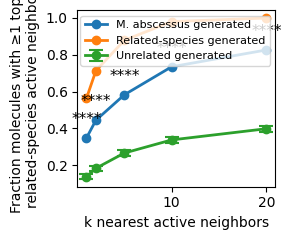

In [30]:
# ============================================================
# Plot panel B
# ============================================================
def plot_panel_b(
    plot_summary,
    fisher_summary,
    error_col="sd_fraction",
):
    query_order = [
        "mabs_generated",
        "related_generated",
        "random_unrelated_generated",
        # "unrelated_actives",
    ]

    query_labels = {
        "mabs_generated": "M. abscessus generated",
        "related_generated": "Related-species generated",
        "random_unrelated_generated": "Unrelated generated",
        "unrelated_actives": "Other-species actives",
    }

    plt.figure(figsize=(3, 2.5))

    for query_set in query_order:
        df = (
            plot_summary[
                plot_summary["query_set"] == query_set
            ]
            .sort_values("k")
        )

        if df.empty:
            continue

        if query_set == "random_unrelated_generated":
            plt.errorbar(
                df["k"],
                df["mean_fraction"],
                yerr=df[error_col],
                marker="o",
                linewidth=2,
                capsize=5,
                capthick=1.5,
                elinewidth=1.5,
                label=query_labels[query_set],
            )
        else:
            plt.plot(
                df["k"],
                df["mean_fraction"],
                marker="o",
                linewidth=2,
                label=query_labels[query_set],
            )

    # Stars: M. abscessus vs unrelated generated
    y_max = plot_summary["mean_fraction"].max()
    offset = max(0.02, y_max * 0.06)

    for k in K_VALUES:
        row = fisher_summary[
            (
                fisher_summary["comparison"]
                == "mabs_generated_vs_random_unrelated_generated"
            )
            & (fisher_summary["k"] == k)
        ]

        if row.empty:
            continue

        star = row.iloc[0]["stars"]

        if star == "ns":
            continue

        mabs_y = plot_summary[
            (plot_summary["query_set"] == "mabs_generated")
            & (plot_summary["k"] == k)
        ]["mean_fraction"].iloc[0]

        plt.text(
            k,
            mabs_y + offset,
            star,
            ha="center",
            va="bottom",
            fontsize=11,
        )

    plt.xlabel("k nearest active neighbors")
    plt.ylabel(
        "Fraction molecules with ≥1 top-3\n"
        "related-species active neighbor"
    )
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


plot_panel_b(
    plot_summary_b,
    fisher_summary,
    error_col="sd_fraction",
)

# C. Closest Tanimoto similarity distributions

In [31]:
# Prepare SMILES sets

mab_gen_smiles = (
    mab_meta["smiles"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

related_active_smiles = (
    active_meta[
        active_meta["active_species"].isin(RELATED_TOP3_SPECIES)
    ]["active_smiles"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

mab_active_smiles = (
    active_meta[
        active_meta["active_species"] == TARGET_BUG
    ]["active_smiles"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

other_active_unique_smiles = (
    unrelated_actives["active_smiles"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

print("M. abscessus generated:", len(mab_gen_smiles))
print("Related species actives:", len(related_active_smiles))
print("M. abscessus actives:", len(mab_active_smiles))
print("Other active molecules:", len(other_active_unique_smiles))

M. abscessus generated: 893
Related species actives: 15020
M. abscessus actives: 186
Other active molecules: 27539


In [32]:
def build_fp_table(smiles_list, set_name, standardize=True):
    rows = []

    for smi in smiles_list:
        if standardize:
            std = standardize_smiles(smi)
        else:
            std = smi
        if std is None:
            continue

        fp = smiles_to_fp(std)
        if fp is None:
            continue

        rows.append({
            "smiles": smi,
            "smiles_std": std,
            "set_name": set_name,
            "fp": fp,
        })

    return pd.DataFrame(rows)


fp_mab_gen = build_fp_table(mab_gen_smiles, "mabs_generated")
fp_related_actives = build_fp_table(related_active_smiles, "related_species_actives", standardize=False)
fp_mab_actives = build_fp_table(mab_active_smiles, "mabs_actives", standardize=False)
fp_other_actives = build_fp_table(other_active_unique_smiles, "other_actives", standardize=False)

print(len(fp_mab_gen), len(fp_related_actives), len(fp_mab_actives), len(fp_other_actives))

[13:01:45] Initializing MetalDisconnector
[13:01:45] Running MetalDisconnector
[13:01:45] Initializing Normalizer
[13:01:45] Running Normalizer
[13:01:45] Running LargestFragmentChooser
[13:01:45] Running Uncharger
[13:01:45] Initializing MetalDisconnector
[13:01:45] Running MetalDisconnector
[13:01:45] Initializing Normalizer
[13:01:45] Running Normalizer
[13:01:45] Running LargestFragmentChooser
[13:01:45] Running Uncharger
[13:01:45] DEPRECATION WARNING: please use MorganGenerator
[13:01:45] Initializing MetalDisconnector
[13:01:45] Running MetalDisconnector
[13:01:45] Initializing Normalizer
[13:01:45] Running Normalizer
[13:01:45] Running LargestFragmentChooser
[13:01:45] Running Uncharger
[13:01:45] Initializing MetalDisconnector
[13:01:45] Running MetalDisconnector
[13:01:45] Initializing Normalizer
[13:01:45] Running Normalizer
[13:01:45] Running LargestFragmentChooser
[13:01:45] Running Uncharger
[13:01:45] DEPRECATION WARNING: please use MorganGenerator
[13:01:45] Initializin

893 15020 186 27539


[13:41:47] DEPRECATION WARNING: please use MorganGenerator
[13:41:47] Initializing MetalDisconnector
[13:41:47] Running MetalDisconnector
[13:41:47] Initializing Normalizer
[13:41:47] Running Normalizer
[13:41:47] Running LargestFragmentChooser
[13:41:47] Running Uncharger
[13:41:47] DEPRECATION WARNING: please use MorganGenerator
[13:41:47] Initializing MetalDisconnector
[13:41:47] Running MetalDisconnector
[13:41:47] Initializing Normalizer
[13:41:47] Running Normalizer
[13:41:47] Running LargestFragmentChooser
[13:41:47] Running Uncharger
[13:41:47] DEPRECATION WARNING: please use MorganGenerator
[13:41:47] Initializing MetalDisconnector
[13:41:47] Running MetalDisconnector
[13:41:47] Initializing Normalizer
[13:41:47] Running Normalizer
[13:41:47] Running LargestFragmentChooser
[13:41:47] Running Uncharger
[13:41:47] DEPRECATION WARNING: please use MorganGenerator


In [33]:
query_fps = fp_mab_gen["fp"].tolist()

# Within generated set: exclude self-match.
# Compute full similarity row-wise, remove self by setting diagonal to nan.
within_sims = []

gen_fps = fp_mab_gen["fp"].tolist()

for i, fp in enumerate(gen_fps):
    sims = np.asarray(DataStructs.BulkTanimotoSimilarity(fp, gen_fps), dtype=float)
    sims[i] = np.nan
    within_sims.append(np.nanmax(sims))

within_sims = np.asarray(within_sims)

closest_to_related_actives = closest_tanimoto_to_set(
    query_fps,
    fp_related_actives["fp"].tolist(),
)

closest_to_mab_actives = closest_tanimoto_to_set(
    query_fps,
    fp_mab_actives["fp"].tolist(),
)

closest_to_other_actives = closest_tanimoto_to_set(
    query_fps,
    fp_other_actives["fp"].tolist(),
)

tanimoto_df = pd.DataFrame({
    "mabs_generated_within_set": within_sims,
    "related_species_actives": closest_to_related_actives,
    "mabs_actives": closest_to_mab_actives,
    "other_actives": closest_to_other_actives,
})

tanimoto_long = tanimoto_df.melt(
    var_name="reference_set",
    value_name="closest_tanimoto_similarity",
)

tanimoto_long.head()

,reference_set,closest_tanimoto_similarity
0,mabs_generated_within_set,0.210526
1,mabs_generated_within_set,0.200000
2,mabs_generated_within_set,0.218391
3,mabs_generated_within_set,0.176471
4,mabs_generated_within_set,0.360000


/tmp/ipykernel_12050/1627149630.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels, showfliers=True)


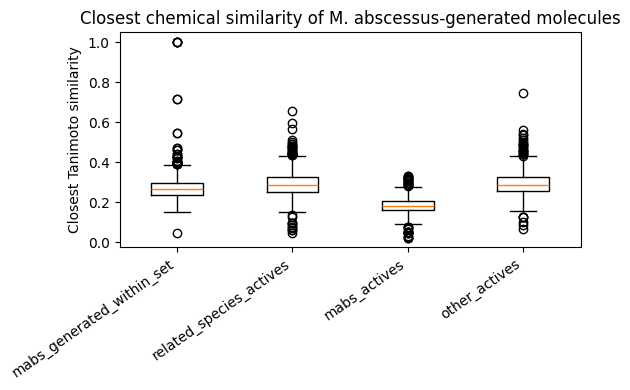

In [34]:
plt.figure(figsize=(6, 4))

labels = [
    "mabs_generated_within_set",
    "related_species_actives",
    "mabs_actives",
    "other_actives",
]

data_to_plot = [
    tanimoto_long.loc[
        tanimoto_long["reference_set"] == label,
        "closest_tanimoto_similarity"
    ].dropna().values
    for label in labels
]

plt.boxplot(data_to_plot, labels=labels, showfliers=True)
plt.ylabel("Closest Tanimoto similarity")
plt.title("Closest chemical similarity of M. abscessus-generated molecules")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

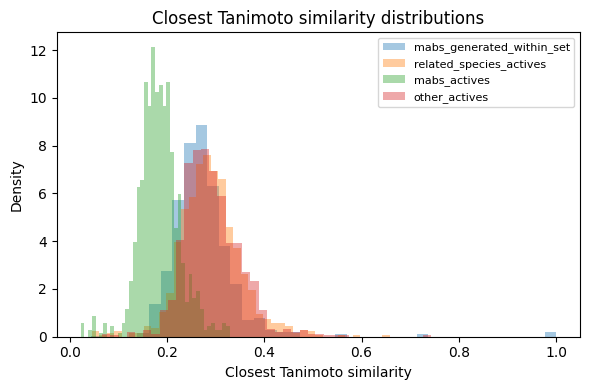

In [35]:
plt.figure(figsize=(6, 4))

for label in labels:
    vals = tanimoto_long.loc[
        tanimoto_long["reference_set"] == label,
        "closest_tanimoto_similarity"
    ].dropna().values

    plt.hist(vals, bins=40, alpha=0.4, density=True, label=label)

plt.xlabel("Closest Tanimoto similarity")
plt.ylabel("Density")
plt.title("Closest Tanimoto similarity distributions")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [36]:
tanimoto_long

,reference_set,closest_tanimoto_similarity
0,mabs_generated_within_set,0.210526
1,mabs_generated_within_set,0.200000
2,mabs_generated_within_set,0.218391
3,mabs_generated_within_set,0.176471
4,mabs_generated_within_set,0.360000
...,...,...
3567,other_actives,0.306452
3568,other_actives,0.153846
3569,other_actives,0.223529
3570,other_actives,0.329412


## Same but for cosine distance in the latent space

In [37]:
related_active_mask = active_meta["active_species"].isin(RELATED_TOP3_SPECIES)

related_active_meta = active_meta[related_active_mask].copy()
related_active_latents = active_latents[related_active_mask.values]

In [38]:
# Rest of active molecules
mabs_actives_mask = (
    active_meta['active_smiles'].notna()
    & ~(active_meta['active_species']=='mycobacteroidesabscessus')
)

mabs_actives_ = (
    active_meta.loc[mabs_actives_mask]
    .copy()
    .reset_index(drop=True)
)

mabs_actives_latents = active_latents[mabs_actives_mask]

mabs_actives_["query_group"] = "unrelated_actives_pool"
mabs_actives_["unrelated_active_index"] = np.arange(
    len(mabs_actives_)
)

assert len(mabs_actives_) == len(mabs_actives_latents)

In [39]:
# related_active_latents
# unrelated_active_latents
# mab_latents
# mabs_actives_latents
# Within generated
# cosine_within_gen = pdist(mab_latents, metric="cosine")

# To related species actives
cosine_to_related_actives = cdist(
    mab_latents,
    related_active_latents,
    metric="cosine",
)

# To M. abscessus actives
cosine_to_mabs_actives = cdist(
    mab_latents,
    mabs_actives_latents,
    metric="cosine",
)

# To other actives
cosine_to_other_actives = cdist(
    mab_latents,
    unrelated_active_latents,
    metric="cosine",
)

# ============================================================
# Closest generated molecule within the M. abscessus set
# ============================================================
cosine_within_gen_matrix = cdist(
    mab_latents,
    mab_latents,
    metric="cosine",
)

# Exclude self-comparisons
np.fill_diagonal(cosine_within_gen_matrix, np.inf)

closest_cosine_within_gen = cosine_within_gen_matrix.min(axis=1)


# ============================================================
# Closest related-species active for each generated molecule
# ============================================================
closest_cosine_to_related_actives = cosine_to_related_actives.min(axis=1)

# ============================================================
# Closest M. abscessus active for each generated molecule
# ============================================================
closest_cosine_to_mabs_actives = cosine_to_mabs_actives.min(axis=1)

# ============================================================
# Closest other-species active for each generated molecule
# ============================================================
closest_cosine_to_other_actives = cosine_to_other_actives.min(axis=1)

In [40]:
cosine_dist_df = pd.DataFrame({
    "mabs_generated_within_set": closest_cosine_within_gen,
    "related_species_actives": closest_cosine_to_related_actives,
    "mabs_actives": closest_cosine_to_mabs_actives,
    "other_actives": closest_cosine_to_other_actives,
})

cosine_dist_df = cosine_dist_df.melt(
    var_name="reference_set",
    value_name="closest_cosine_distance",
)

cosine_dist_df.head()

,reference_set,closest_cosine_distance
0,mabs_generated_within_set,0.429959
1,mabs_generated_within_set,0.378849
2,mabs_generated_within_set,0.402590
3,mabs_generated_within_set,0.403926
4,mabs_generated_within_set,0.501031


# Nice plot A, B, C

In [41]:

def clean_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(length=3, width=0.8)


def p_to_stars_for_plot(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


species_short = {
    "mycobacteriumtuberculosis": "M. tuberculosis",
    "staphylococcusaureus": "S. aureus",
    "escherichiacoli": "E. coli",
    "pseudomonasaeruginosa": "P. aeruginosa",
    "bacillussubtilis": "B. subtilis",
    "streptococcuspneumoniae": "S. pneumoniae",
    "staphylococcusepidermidis": "S. epidermidis",
    "streptococcusmutans": "S. mutans",
    "enterococcusfaecalis": "E. faecalis",
    "enterococcusfaecium": "E. faecium",
    "mycobacteriumavium": "M. avium",
    "mycobacteriumulcerans": "M. ulcerans",
    "klebsiellapneumoniae": "K. pneumoniae",
    "acinetobacterbaumannii": "A. baumannii",
}

In [42]:
plot_summary_b

,query_set,k,mean_fraction,sd_fraction,ci95_fraction,n_repeats
0,mabs_generated,1,0.347778,0.000000,0.000000,1
1,mabs_generated,2,0.444444,0.000000,0.000000,1
2,mabs_generated,5,0.582222,0.000000,0.000000,1
3,mabs_generated,10,0.734444,0.000000,0.000000,1
4,mabs_generated,20,0.825556,0.000000,0.000000,1
5,related_generated,1,0.563333,0.000000,0.000000,1
6,related_generated,2,0.713333,0.000000,0.000000,1
7,related_generated,5,0.878148,0.000000,0.000000,1
8,related_generated,10,0.979630,0.000000,0.000000,1
9,related_generated,20,0.998889,0.000000,0.000000,1


In [ ]:
import seaborn as sns
paired = sns.color_palette("muted")

COLORS = {
    "random_generated": 'tab:grey',
    "mabs_generated": paired[1],
    "other_actives": paired[2],
    "related_species": paired[3],
}

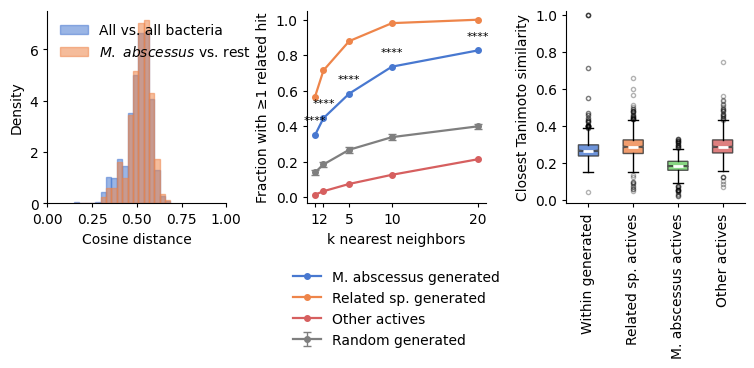

In [126]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(9, 2.5),
    gridspec_kw={"wspace": 0.45},
)

axA, axB, axD = axes

# -----------------------------
# Plot A
# -----------------------------
bin_width = 0.03

x_all = species_similarity.query("bug_species != @TARGET_BUG")["distance_to_mabs"]
x_active_mab = active_supported_species_similarity['distance_to_mabs'].values

x_min = min(x_all.min(), x_active_mab.min())
x_max = max(x_all.max(), x_active_mab.max())

bins = np.arange(x_min, x_max + bin_width, bin_width)

axA.hist(
    x_all,
    bins=bins,
    alpha=0.55,
    color=paired[0],
    edgecolor=paired[0],
    label="All vs. all bacteria",
    density=True,
)

axA.hist(
    x_active_mab,
    bins=bins,
    alpha=0.55,
    color=paired[1],
    edgecolor=paired[1],
    label=r"$\it{M.\ abscessus}$ vs. rest",
    density=True,
)

axA.set_xlabel("Cosine distance")
axA.set_ylabel("Density")
axA.legend(frameon=False, loc="upper left")
clean_ax(axA)


# -----------------------------
# Plot B
# -----------------------------
query_order = [
    "mabs_generated",
    "related_generated",
    "random_unrelated_generated",
    "unrelated_actives",
]

pretty_labels = {
    "mabs_generated": "M. abscessus generated",
    "related_generated": "Related sp. generated",
    "random_unrelated_generated": "Random generated",
    "unrelated_actives": "Other actives",
}

plot_colors = {
    "mabs_generated": paired[0],
    "related_generated": paired[1],
    "random_unrelated_generated": 'tab:grey',
    "unrelated_actives": paired[3],
}

for query_set in query_order:
    df = plot_summary_b[plot_summary_b["query_set"] == query_set].sort_values("k")

    if query_set in ["mabs_generated", "related_generated", "unrelated_actives"]:
        axB.plot(
            df["k"],
            df["mean_fraction"],
            marker="o",
            linewidth=1.6,
            markersize=4,
            color=plot_colors[query_set],
            label=pretty_labels[query_set],
        )
    else:
        axB.errorbar(
            df["k"],
            df["mean_fraction"],
            yerr=df["sd_fraction"],
            marker="o",
            linewidth=1.6,
            markersize=4,
            capsize=3,
            capthick=1,
            elinewidth=1,
            color=plot_colors[query_set],
            label=pretty_labels[query_set],
        )

# Fisher stars: M. abscessus vs random unrelated generated
y_max = plot_summary_b["mean_fraction"].max()
offset = max(0.025, y_max * 0.055)

for k in K_VALUES:
    row = fisher_summary[
        (fisher_summary["comparison"] == "mabs_generated_vs_random_unrelated_generated")
        & (fisher_summary["k"] == k)
    ]

    if len(row) == 0:
        continue

    star = row.iloc[0]["stars"]
    if star == "ns":
        continue

    mabs_y = plot_summary_b[
        (plot_summary_b["query_set"] == "mabs_generated")
        & (plot_summary_b["k"] == k)
    ]["mean_fraction"].iloc[0]

    axB.text(
        k,
        mabs_y + offset,
        star,
        ha="center",
        va="bottom",
        fontsize=8,
    )

axB.set_xlabel("k nearest neighbors")
axB.set_ylabel("Fraction with ≥1 related hit")
# axB.legend(frameon=False, loc="lower right")
clean_ax(axB)
axB.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=1,
)

# -----------------------------
# Plot C — example-figure style boxplot
# -----------------------------
label_order = [
    "mabs_generated_within_set",
    "related_species_actives",
    "mabs_actives",
    "other_actives",
]

label_pretty = {
    "mabs_generated_within_set": "Within generated",
    "related_species_actives": "Related sp. actives",
    "mabs_actives": "M. abscessus actives",
    "other_actives": "Other actives",
}

box_colors = {
    "mabs_generated_within_set": paired[0],
    "related_species_actives": paired[1],
    "mabs_actives": paired[2],
    "other_actives": paired[3],
}

box_data = [
    tanimoto_long.loc[
        tanimoto_long["reference_set"] == label,
        "closest_tanimoto_similarity"
    ].dropna().values
    for label in label_order
]

# bp = axD.boxplot(
#     box_data,
#     patch_artist=True,
#     widths=0.55,
#     showfliers=False,
#     medianprops={"color": "black", "linewidth": 1.2},
#     boxprops={"linewidth": 1.0},
#     whiskerprops={"linewidth": 1.0},
#     capprops={"linewidth": 1.0},
# )

# Keep default matplotlib color cycle but apply soft fills
# for patch in bp["boxes"]:
#     patch.set_alpha(0.65)

# Jittered points, like in your example figures
rng = np.random.default_rng(SEED)

bp = axD.boxplot(box_data, patch_artist=True, notch=True, 
                medianprops={'color': 'white', 'linewidth': 2},
                flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3})

for patch, label in zip(bp["boxes"], label_order):
    patch.set_facecolor(box_colors[label])
    patch.set_edgecolor("#333333")
    patch.set_alpha(0.8)

axD.set_xticks(np.arange(1, len(label_order) + 1))
axD.set_xticklabels([label_pretty[x] for x in label_order], rotation=90)
axD.set_ylabel("Closest Tanimoto similarity")
axD.set_ylim(-0.02, 1.02)
clean_ax(axD)

axA.set_xlim(0,1)
axB.set_xticks(K_VALUES)
# fig.savefig(OUTDIR / "mabs_figure_row1_A_B_D.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
cosine_dist_df.groupby("reference_set")["closest_cosine_distance"].describe()

,count,mean,std,min,25%,50%,75%,max
reference_set,,,,,,,,
mabs_actives,900.0,0.401452,0.059033,0.134020,0.372999,0.408106,0.441847,0.528415
mabs_generated_within_set,900.0,0.371757,0.058380,0.158332,0.338028,0.375387,0.408998,0.537665
other_actives,900.0,0.411817,0.062460,0.134020,0.380358,0.417914,0.456202,0.544818
related_species_actives,900.0,0.428233,0.057178,0.162002,0.399542,0.434022,0.466025,0.555591


In [ ]:
tanimoto_long.groupby("reference_set")["closest_tanimoto_similarity"].describe()

,count,mean,std,min,25%,50%,75%,max
reference_set,,,,,,,,
mabs_actives,893.0,0.184386,0.041957,0.022727,0.159420,0.181818,0.207792,0.329114
mabs_generated_within_set,893.0,0.274094,0.074479,0.043478,0.236364,0.264706,0.296875,1.000000
other_actives,893.0,0.292596,0.060334,0.066667,0.252874,0.285714,0.323529,0.743590
related_species_actives,893.0,0.290590,0.064041,0.045455,0.250000,0.285714,0.323529,0.657895


# D. Active-neighbor provenance at k = 1 with random expectation

In [57]:
# Observed top-1 active neighbor provenance for M. abscessus-generated molecules
n_neigh = 1
top1_mab = neighbors_mab[neighbors_mab["neighbor_rank"] <= n_neigh].copy()

observed_counts = (
    top1_mab["neighbor_active_species"]
    .value_counts()
    .rename("observed_count")
    .reset_index()
    .rename(columns={"index": "species"})
)

observed_counts.head()

,neighbor_active_species,observed_count
0,mycobacteriumtuberculosis,310
1,staphylococcusaureus,237
2,escherichiacoli,68
3,pseudomonasaeruginosa,36
4,bacillussubtilis,32


In [58]:
# Random expectation from active-pair proportions.
# Because active_meta is pair-based, molecules active against several bacteria are counted several times.
active_pair_counts = (
    active_meta
    .dropna(subset=["active_species"])
    .groupby("active_species")
    .size()
    .rename("n_active_pairs")
    .reset_index()
    .rename(columns={"active_species": "species"})
)

n_neighbors_evaluated = len(top1_mab)

total_active_pairs = active_pair_counts["n_active_pairs"].sum()

active_pair_counts["expected_count"] = (
    n_neighbors_evaluated
    * active_pair_counts["n_active_pairs"]
    / total_active_pairs
)

provenance = observed_counts.merge(
    active_pair_counts[["species", "expected_count", "n_active_pairs"]],
    right_on="species",
    left_on='neighbor_active_species',
    how="outer",
).fillna({"observed_count": 0, "expected_count": 0})

provenance = provenance.sort_values("observed_count", ascending=False).reset_index(drop=True)

provenance.head(20)

,neighbor_active_species,observed_count,species,expected_count,n_active_pairs
0,mycobacteriumtuberculosis,310.0,mycobacteriumtuberculosis,143.486608,14947
1,staphylococcusaureus,237.0,staphylococcusaureus,171.469713,17862
2,escherichiacoli,68.0,escherichiacoli,99.731209,10389
3,pseudomonasaeruginosa,36.0,pseudomonasaeruginosa,48.430450,5045
4,bacillussubtilis,32.0,bacillussubtilis,32.350965,3370
5,streptococcuspneumoniae,24.0,streptococcuspneumoniae,42.469041,4424
6,staphylococcusepidermidis,22.0,staphylococcusepidermidis,36.171643,3768
7,enterococcusfaecalis,16.0,enterococcusfaecalis,45.214553,4710
8,streptococcusmutans,16.0,streptococcusmutans,1.919939,200
9,enterococcusfaecium,14.0,enterococcusfaecium,20.456945,2131


In [59]:
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

# Total number of top-1 neighbors evaluated
n_neighbors_evaluated = len(top1_mab)

# Make sure provenance contains:
# species, observed_count, expected_count, n_active_pairs
provenance_stats = provenance.copy()

# Background probability for each species
provenance_stats["background_prob"] = (
    provenance_stats["n_active_pairs"] / provenance_stats["n_active_pairs"].sum()
)

# Fold-enrichment observed / expected
provenance_stats["fold_enrichment"] = (
    provenance_stats["observed_count"] / provenance_stats["expected_count"]
)

# One-sided binomial test: observed > expected
pvals = []

for row in provenance_stats.itertuples(index=False):
    x = int(row.observed_count)
    p = float(row.background_prob)
    
    if p == 0:
        pvals.append(np.nan)
    else:
        res = binomtest(
            k=x,
            n=n_neighbors_evaluated,
            p=p,
            alternative="greater",
        )
        pvals.append(res.pvalue)

provenance_stats["binom_p_greater"] = pvals

# Multiple-testing correction across species
mask = provenance_stats["binom_p_greater"].notna()

provenance_stats.loc[mask, "binom_q_fdr"] = multipletests(
    provenance_stats.loc[mask, "binom_p_greater"],
    method="fdr_bh",
)[1]

def p_to_stars(p):
    if pd.isna(p):
        return ""
    elif p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

provenance_stats["stars_fdr"] = provenance_stats["binom_q_fdr"].apply(p_to_stars)

provenance_stats = provenance_stats.sort_values("observed_count", ascending=False)

provenance_stats[
    [
        "species",
        "observed_count",
        "expected_count",
        "fold_enrichment",
        "background_prob",
        "binom_p_greater",
        "binom_q_fdr",
        "stars_fdr",
    ]
].head(20)

,species,observed_count,expected_count,fold_enrichment,background_prob,binom_p_greater,binom_q_fdr,stars_fdr
0,mycobacteriumtuberculosis,310.0,143.486608,2.160480,0.159430,4.249529e-42,1.155872e-39,****
1,staphylococcusaureus,237.0,171.469713,1.382168,0.190522,5.765471e-08,5.227360e-06,****
2,escherichiacoli,68.0,99.731209,0.681833,0.110812,9.998390e-01,1.000000e+00,ns
3,pseudomonasaeruginosa,36.0,48.430450,0.743334,0.053812,9.760176e-01,1.000000e+00,ns
4,bacillussubtilis,32.0,32.350965,0.989151,0.035946,5.497731e-01,1.000000e+00,ns
5,streptococcuspneumoniae,24.0,42.469041,0.565118,0.047188,9.993599e-01,1.000000e+00,ns
6,staphylococcusepidermidis,22.0,36.171643,0.608211,0.040191,9.960784e-01,1.000000e+00,ns
7,enterococcusfaecalis,16.0,45.214553,0.353868,0.050238,9.999999e-01,1.000000e+00,ns
8,streptococcusmutans,16.0,1.919939,8.333600,0.002133,2.424778e-10,3.297699e-08,****
9,enterococcusfaecium,14.0,20.456945,0.684364,0.022730,9.472632e-01,1.000000e+00,ns


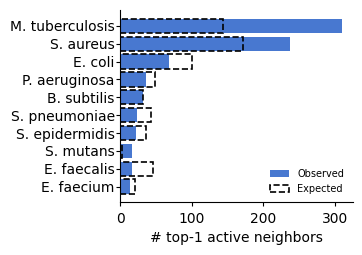

In [ ]:
TOP_N_PROVENANCE = 10

plot_prov = provenance.head(TOP_N_PROVENANCE).copy()
plot_prov = plot_prov.sort_values("observed_count", ascending=True)

plot_prov["species_label"] = plot_prov["species"].map(species_short).fillna(plot_prov["species"])

y = np.arange(len(plot_prov))

fig, ax = plt.subplots(figsize=(3, 2.5))

ax.barh(
    y,
    plot_prov["observed_count"],
    label="Observed",
    color=paired[0],
)

ax.barh(
    y,
    plot_prov["expected_count"],
    facecolor="none",
    edgecolor="black",
    linestyle="--",
    linewidth=1.2,
    label="Expected",
)

ax.set_yticks(y)
ax.set_yticklabels(plot_prov["species_label"])
ax.tick_params(axis="y", pad=1)

ax.set_xlabel("# top-1 active neighbors")
ax.legend(frameon=False, fontsize=7, loc="lower right")
clean_ax(ax)

plt.show()

# E. tSNE plot of the same molecule sets

In [63]:
# tSNE but using latents instead of Morgan fingerprints
MAX_PER_SET_TSNE = 10000

def sample_rows_and_latents(meta_df, latents, max_n, seed):
    """
    Samples rows from meta_df and the corresponding rows from latents.
    Assumes meta_df rows and latents rows are aligned.
    """
    meta_df = meta_df.copy().reset_index(drop=True)

    if len(meta_df) <= max_n:
        idx = np.arange(len(meta_df))
    else:
        idx = meta_df.sample(n=max_n, random_state=seed).index.values

    return meta_df.iloc[idx].copy().reset_index(drop=True), latents[idx]


# -----------------------------
# 1. M. abscessus generated
# -----------------------------
tsne_mab_gen_meta, tsne_mab_gen_latents = sample_rows_and_latents(
    mab_meta,
    mab_latents,
    MAX_PER_SET_TSNE,
    SEED,
)

tsne_mab_gen_meta["set_name"] = "mabs_generated"


# -----------------------------
# 2. Related-species actives
# -----------------------------


tsne_related_active_meta, tsne_related_active_latents = sample_rows_and_latents(
    related_active_meta,
    related_active_latents,
    MAX_PER_SET_TSNE,
    SEED + 1,
)

tsne_related_active_meta["set_name"] = "related_species_actives"


# -----------------------------
# 3. M. abscessus actives
# -----------------------------
mab_active_mask = active_meta["active_species"] == TARGET_BUG

mab_active_meta = active_meta[mab_active_mask].copy()
mab_active_latents_for_tsne = active_latents[mab_active_mask.values]

tsne_mab_active_meta, tsne_mab_active_latents = sample_rows_and_latents(
    mab_active_meta,
    mab_active_latents_for_tsne,
    MAX_PER_SET_TSNE,
    SEED + 2,
)

tsne_mab_active_meta["set_name"] = "mabs_actives"


# -----------------------------
# 4. Random actives
# -----------------------------
all_active_idx = np.arange(len(unrelated_actives))

if len(unrelated_actives) <= MAX_PER_SET_TSNE:
    random_active_idx = all_active_idx
else:
    random_active_idx = (
        unrelated_actives
        .sample(n=MAX_PER_SET_TSNE, random_state=SEED + 3)
        .index
        .values
    )

tsne_random_active_meta = unrelated_actives.iloc[random_active_idx].copy().reset_index(drop=True)
tsne_random_active_latents = unrelated_active_latents[random_active_idx]

tsne_random_active_meta["set_name"] = "random_actives"


# -----------------------------
# Combine
# -----------------------------
latent_tsne_meta = pd.concat(
    [
        tsne_mab_gen_meta,
        tsne_related_active_meta,
        tsne_mab_active_meta,
        tsne_random_active_meta,
    ],
    ignore_index=True,
)

latent_tsne_X = np.vstack(
    [
        tsne_mab_gen_latents,
        tsne_related_active_latents,
        tsne_mab_active_latents,
        tsne_random_active_latents,
    ]
)

print(latent_tsne_meta.groupby("set_name").size())
print(latent_tsne_X.shape)

set_name
mabs_actives                 186
mabs_generated               900
random_actives             10000
related_species_actives    10000
dtype: int64
(21086, 300)


In [64]:
from sklearn.manifold import TSNE

tsne_latent = TSNE(
    n_components=2,
    metric="cosine",
    perplexity=30,
    init="random",
    learning_rate="auto",
    random_state=SEED,
)

latent_coords = tsne_latent.fit_transform(latent_tsne_X)

latent_tsne_meta["tsne_1"] = latent_coords[:, 0]
latent_tsne_meta["tsne_2"] = latent_coords[:, 1]

latent_tsne_meta.head()

,generated_id,species_generated_for,smiles,local_generated_index,batch_number,query_group,set_name,active_smiles,active_species,active_pair_id,unrelated_active_index,tsne_1,tsne_2
0,mycobacteroidesabscessus__0,mycobacteroidesabscessus,Cc1ccn(-c2c(Cl)cnc3[nH]cc(C4CCCCC4)c(=O)c23)n1,0.0,0.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,21.236074,41.183559
1,mycobacteroidesabscessus__1,mycobacteroidesabscessus,C=C=C,1.0,1.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,27.210190,51.395340
2,mycobacteroidesabscessus__2,mycobacteroidesabscessus,CCC1CCC(=O)C(C(C)=NCc2ccc(Oc3ncc(C)s3)cc2)C1,2.0,2.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,27.865480,41.171009
3,mycobacteroidesabscessus__3,mycobacteroidesabscessus,CN(C)S(=O)(=O)c1ccc(-c2coc(S)c2)cc1,3.0,3.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,20.857891,33.554440
4,mycobacteroidesabscessus__4,mycobacteroidesabscessus,Cc1ccc(NP(=O)(O)CN=C(O)c2ccc(C)cc2)cc1,4.0,4.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,-38.196999,-43.011230


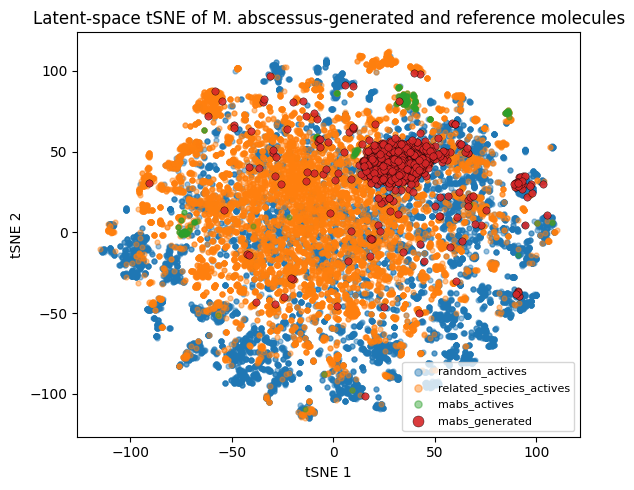

In [65]:
plt.figure(figsize=(6, 5))

plot_order = [
    "random_actives",
    "related_species_actives",
    "mabs_actives",
    "mabs_generated",  # last = plotted on top
]

for set_name in plot_order:
    df_set = latent_tsne_meta[latent_tsne_meta["set_name"] == set_name]

    if set_name == "mabs_generated":
        plt.scatter(
            df_set["tsne_1"],
            df_set["tsne_2"],
            s=28,
            alpha=0.9,
            label=set_name,
            edgecolors="black",
            linewidths=0.3,
            zorder=10,
        )
    else:
        plt.scatter(
            df_set["tsne_1"],
            df_set["tsne_2"],
            s=12,
            alpha=0.45,
            label=set_name,
            zorder=1,
        )

plt.xlabel("tSNE 1")
plt.ylabel("tSNE 2")
plt.title("Latent-space tSNE of M. abscessus-generated and reference molecules")
plt.legend(fontsize=8, markerscale=1.5)
plt.tight_layout()
plt.show()

## Select molecules to show

In [67]:
# Keep top-1 active neighbor for each M. abscessus generated molecule
mabs_top1_active = (
    neighbors_mab
    .sort_values(["generated_id", "neighbor_rank", "neighbor_latent_cosine_distance"])
    .groupby("generated_id", as_index=False)
    .first()
)

mabs_tsne = latent_tsne_meta[latent_tsne_meta["set_name"] == "mabs_generated"].copy()

# Merge top-1 active info
mabs_tsne = mabs_tsne.merge(
    mabs_top1_active[
        [
            "generated_id",
            "neighbor_active_smiles",
            "neighbor_active_species",
            "neighbor_latent_cosine_distance",
            "neighbor_rank",
        ]
    ],
    on="generated_id",
    how="left",
)

mabs_tsne.head()

,generated_id,species_generated_for,smiles,local_generated_index,batch_number,query_group,set_name,active_smiles,active_species,active_pair_id,unrelated_active_index,tsne_1,tsne_2,neighbor_active_smiles,neighbor_active_species,neighbor_latent_cosine_distance,neighbor_rank
0,mycobacteroidesabscessus__0,mycobacteroidesabscessus,Cc1ccn(-c2c(Cl)cnc3[nH]cc(C4CCCCC4)c(=O)c23)n1,0.0,0.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,21.236074,41.183559,CN1CCCN(c2nc(C3CCCC3)nc3c2cnn3C)CC1,mycobacteriumtuberculosis,0.445422,1
1,mycobacteroidesabscessus__1,mycobacteroidesabscessus,C=C=C,1.0,1.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,27.210190,51.395340,Cc1cccc(Oc2ccc(-c3nc(N)nc(N)n3)cc2)c1C,mycobacteriumtuberculosis,0.445383,1
2,mycobacteroidesabscessus__2,mycobacteroidesabscessus,CCC1CCC(=O)C(C(C)=NCc2ccc(Oc3ncc(C)s3)cc2)C1,2.0,2.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,27.865480,41.171009,COc1ccc2nc(C)cc(OCC(=O)NC3CCC(C)CC3)c2c1,mycobacteriumtuberculosis,0.393320,1
3,mycobacteroidesabscessus__3,mycobacteroidesabscessus,CN(C)S(=O)(=O)c1ccc(-c2coc(S)c2)cc1,3.0,3.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,20.857891,33.554440,CC(C)(C)c1ccc(S(=O)(=O)N2CCSC2)cc1,escherichiacoli,0.380049,1
4,mycobacteroidesabscessus__4,mycobacteroidesabscessus,Cc1ccc(NP(=O)(O)CN=C(O)c2ccc(C)cc2)cc1,4.0,4.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,-38.196999,-43.011230,Cc1ccc(N2CCN(C)CC2)c2c1CC[C@H](NC(=O)c1ccc(Oc3...,mycobacteriumtuberculosis,0.427610,1


In [68]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.MolStandardize import rdMolStandardize

def standardize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        mol = rdMolStandardize.Cleanup(mol)
        mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
        mol = rdMolStandardize.Uncharger().uncharge(mol)
        mol = rdMolStandardize.TautomerEnumerator().Canonicalize(mol)
        Chem.SanitizeMol(mol)
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return None

def smiles_to_fp(smiles, radius=2, n_bits=2048):
    smi = standardize_smiles(smiles)
    if smi is None:
        return None
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)

def tanimoto_pair(smi1, smi2):
    fp1 = smiles_to_fp(smi1)
    fp2 = smiles_to_fp(smi2)
    if fp1 is None or fp2 is None:
        return np.nan
    return DataStructs.TanimotoSimilarity(fp1, fp2)

mabs_tsne["tanimoto_to_top1_active"] = mabs_tsne.apply(
    lambda r: tanimoto_pair(r["smiles"], r["neighbor_active_smiles"]),
    axis=1,
)

mabs_tsne.head()

[15:27:51] Initializing MetalDisconnector
[15:27:51] Running MetalDisconnector
[15:27:51] Initializing Normalizer
[15:27:51] Running Normalizer
[15:27:51] Running LargestFragmentChooser
[15:27:51] Running Uncharger
[15:27:51] DEPRECATION WARNING: please use MorganGenerator
[15:27:51] Initializing MetalDisconnector
[15:27:51] Running MetalDisconnector
[15:27:51] Initializing Normalizer
[15:27:51] Running Normalizer
[15:27:51] Running LargestFragmentChooser
[15:27:51] Running Uncharger
[15:27:51] DEPRECATION WARNING: please use MorganGenerator
[15:27:51] Initializing MetalDisconnector
[15:27:51] Running MetalDisconnector
[15:27:51] Initializing Normalizer
[15:27:51] Running Normalizer
[15:27:51] Running LargestFragmentChooser
[15:27:51] Running Uncharger
[15:27:51] DEPRECATION WARNING: please use MorganGenerator
[15:27:51] Initializing MetalDisconnector
[15:27:51] Running MetalDisconnector
[15:27:51] Initializing Normalizer
[15:27:51] Running Normalizer
[15:27:51] Running LargestFragment

,generated_id,species_generated_for,smiles,local_generated_index,batch_number,query_group,set_name,active_smiles,active_species,active_pair_id,unrelated_active_index,tsne_1,tsne_2,neighbor_active_smiles,neighbor_active_species,neighbor_latent_cosine_distance,neighbor_rank,tanimoto_to_top1_active
0,mycobacteroidesabscessus__0,mycobacteroidesabscessus,Cc1ccn(-c2c(Cl)cnc3[nH]cc(C4CCCCC4)c(=O)c23)n1,0.0,0.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,21.236074,41.183559,CN1CCCN(c2nc(C3CCCC3)nc3c2cnn3C)CC1,mycobacteriumtuberculosis,0.445422,1,0.166667
1,mycobacteroidesabscessus__1,mycobacteroidesabscessus,C=C=C,1.0,1.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,27.210190,51.395340,Cc1cccc(Oc2ccc(-c3nc(N)nc(N)n3)cc2)c1C,mycobacteriumtuberculosis,0.445383,1,0.000000
2,mycobacteroidesabscessus__2,mycobacteroidesabscessus,CCC1CCC(=O)C(C(C)=NCc2ccc(Oc3ncc(C)s3)cc2)C1,2.0,2.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,27.865480,41.171009,COc1ccc2nc(C)cc(OCC(=O)NC3CCC(C)CC3)c2c1,mycobacteriumtuberculosis,0.393320,1,0.179775
3,mycobacteroidesabscessus__3,mycobacteroidesabscessus,CN(C)S(=O)(=O)c1ccc(-c2coc(S)c2)cc1,3.0,3.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,20.857891,33.554440,CC(C)(C)c1ccc(S(=O)(=O)N2CCSC2)cc1,escherichiacoli,0.380049,1,0.166667
4,mycobacteroidesabscessus__4,mycobacteroidesabscessus,Cc1ccc(NP(=O)(O)CN=C(O)c2ccc(C)cc2)cc1,4.0,4.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,-38.196999,-43.011230,Cc1ccc(N2CCN(C)CC2)c2c1CC[C@H](NC(=O)c1ccc(Oc3...,mycobacteriumtuberculosis,0.427610,1,0.183099


In [69]:
from sklearn.cluster import DBSCAN

X_mabs = mabs_tsne[["tsne_1", "tsne_2"]].values

# You may need to tune eps a bit depending on the scale of your tSNE
db = DBSCAN(eps=8, min_samples=8)
mabs_tsne["tsne_cluster"] = db.fit_predict(X_mabs)

mabs_tsne["tsne_cluster"].value_counts().sort_values(ascending=False)

tsne_cluster
 0    780
-1     97
 1     23
Name: count, dtype: int64

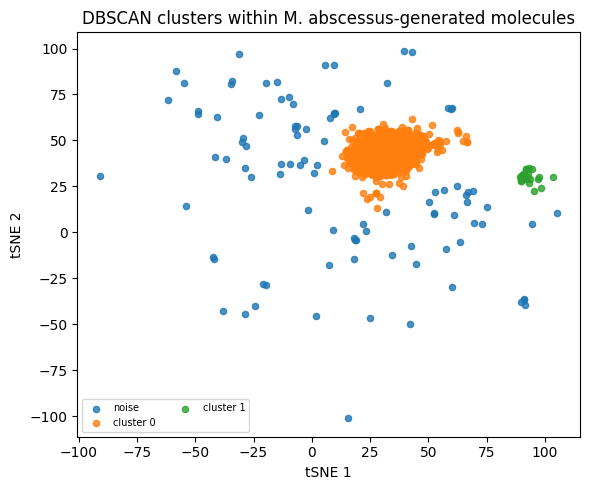

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

for cl, df_cl in mabs_tsne.groupby("tsne_cluster"):
    label = f"cluster {cl}" if cl != -1 else "noise"
    plt.scatter(
        df_cl["tsne_1"],
        df_cl["tsne_2"],
        s=20,
        alpha=0.8,
        label=label,
    )

plt.xlabel("tSNE 1")
plt.ylabel("tSNE 2")
plt.title("DBSCAN clusters within M. abscessus-generated molecules")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

In [71]:
cluster_sizes = (
    mabs_tsne[mabs_tsne["tsne_cluster"] != -1]
    .groupby("tsne_cluster")
    .size()
    .sort_values(ascending=False)
)

central_cluster = cluster_sizes.index[0]
print("Central cluster:", central_cluster)
print(cluster_sizes.head(10))

Central cluster: 0
tsne_cluster
0    780
1     23
dtype: int64


In [72]:
central_df = mabs_tsne[mabs_tsne["tsne_cluster"] == central_cluster].copy()

centroid = central_df[["tsne_1", "tsne_2"]].mean().values
central_df["dist_to_cluster_centroid"] = np.sqrt(
    ((central_df[["tsne_1", "tsne_2"]].values - centroid) ** 2).sum(axis=1)
)

central_candidates = central_df[
    central_df["tanimoto_to_top1_active"].between(0.2, 0.8)
].copy()

if len(central_candidates) == 0:
    central_candidates = central_df.copy()

central_pick = central_candidates.sort_values(
    ["dist_to_cluster_centroid", "neighbor_latent_cosine_distance"]
).head(1)

central_pick

,generated_id,species_generated_for,smiles,local_generated_index,batch_number,query_group,set_name,active_smiles,active_species,active_pair_id,unrelated_active_index,tsne_1,tsne_2,neighbor_active_smiles,neighbor_active_species,neighbor_latent_cosine_distance,neighbor_rank,tanimoto_to_top1_active,tsne_cluster,dist_to_cluster_centroid
636,mycobacteroidesabscessus__636,mycobacteroidesabscessus,COc1ccc(-c2sccc2CCOc2ccc3ccccc3c2)cc1Cl,636.0,636.0,mabs_generated,mabs_generated,NaN,NaN,NaN,NaN,30.93815,42.801189,COc1ccc(/C=C/C(=O)c2cc(Cl)c(Cl)[nH]2)cc1OC,staphylococcusaureus,0.42625,1,0.211268,0,1.484166


In [73]:
from sklearn.neighbors import NearestNeighbors

all_tsne = latent_tsne_meta.copy().reset_index(drop=True)

# Build a nearest-neighbor structure in tSNE space over all plotted points
nn_tsne = NearestNeighbors(n_neighbors=25, metric="euclidean")
nn_tsne.fit(all_tsne[["tsne_1", "tsne_2"]].values)

mabs_indices_in_all = all_tsne.index[all_tsne["set_name"] == "mabs_generated"].tolist()

rows = []

for idx in mabs_indices_in_all:
    dists, nbrs = nn_tsne.kneighbors(
        all_tsne.loc[[idx], ["tsne_1", "tsne_2"]].values,
        return_distance=True,
    )
    nbrs = nbrs[0]
    nbr_df = all_tsne.iloc[nbrs]

    frac_mabs_actives = np.mean(nbr_df["set_name"] == "mabs_actives")
    frac_related_actives = np.mean(nbr_df["set_name"] == "related_species_actives")

    rows.append({
        "generated_id": all_tsne.loc[idx, "generated_id"],
        "frac_mabs_actives_local": frac_mabs_actives,
        "frac_related_actives_local": frac_related_actives,
    })

local_enrichment = pd.DataFrame(rows)

mabs_tsne = mabs_tsne.merge(local_enrichment, on="generated_id", how="left")
mabs_tsne.head()

,generated_id,species_generated_for,smiles,local_generated_index,batch_number,query_group,set_name,active_smiles,active_species,active_pair_id,...,tsne_1,tsne_2,neighbor_active_smiles,neighbor_active_species,neighbor_latent_cosine_distance,neighbor_rank,tanimoto_to_top1_active,tsne_cluster,frac_mabs_actives_local,frac_related_actives_local
0,mycobacteroidesabscessus__0,mycobacteroidesabscessus,Cc1ccn(-c2c(Cl)cnc3[nH]cc(C4CCCCC4)c(=O)c23)n1,0.0,0.0,mabs_generated,mabs_generated,NaN,NaN,NaN,...,21.236074,41.183559,CN1CCCN(c2nc(C3CCCC3)nc3c2cnn3C)CC1,mycobacteriumtuberculosis,0.445422,1,0.166667,0,0.0,0.00
1,mycobacteroidesabscessus__1,mycobacteroidesabscessus,C=C=C,1.0,1.0,mabs_generated,mabs_generated,NaN,NaN,NaN,...,27.210190,51.395340,Cc1cccc(Oc2ccc(-c3nc(N)nc(N)n3)cc2)c1C,mycobacteriumtuberculosis,0.445383,1,0.000000,0,0.0,0.00
2,mycobacteroidesabscessus__2,mycobacteroidesabscessus,CCC1CCC(=O)C(C(C)=NCc2ccc(Oc3ncc(C)s3)cc2)C1,2.0,2.0,mabs_generated,mabs_generated,NaN,NaN,NaN,...,27.865480,41.171009,COc1ccc2nc(C)cc(OCC(=O)NC3CCC(C)CC3)c2c1,mycobacteriumtuberculosis,0.393320,1,0.179775,0,0.0,0.00
3,mycobacteroidesabscessus__3,mycobacteroidesabscessus,CN(C)S(=O)(=O)c1ccc(-c2coc(S)c2)cc1,3.0,3.0,mabs_generated,mabs_generated,NaN,NaN,NaN,...,20.857891,33.554440,CC(C)(C)c1ccc(S(=O)(=O)N2CCSC2)cc1,escherichiacoli,0.380049,1,0.166667,0,0.0,0.04
4,mycobacteroidesabscessus__4,mycobacteroidesabscessus,Cc1ccc(NP(=O)(O)CN=C(O)c2ccc(C)cc2)cc1,4.0,4.0,mabs_generated,mabs_generated,NaN,NaN,NaN,...,-38.196999,-43.011230,Cc1ccc(N2CCN(C)CC2)c2c1CC[C@H](NC(=O)c1ccc(Oc3...,mycobacteriumtuberculosis,0.427610,1,0.183099,-1,0.0,0.96


In [74]:
mabs_active_region_candidates = mabs_tsne[
    mabs_tsne["tanimoto_to_top1_active"].between(0.2, 0.8)
].copy()

if len(mabs_active_region_candidates) == 0:
    mabs_active_region_candidates = mabs_tsne.copy()

mabs_active_region_pick = mabs_active_region_candidates.sort_values(
    ["frac_mabs_actives_local", "neighbor_latent_cosine_distance"],
    ascending=[False, True]
).head(1)

mabs_active_region_pick

,generated_id,species_generated_for,smiles,local_generated_index,batch_number,query_group,set_name,active_smiles,active_species,active_pair_id,...,tsne_1,tsne_2,neighbor_active_smiles,neighbor_active_species,neighbor_latent_cosine_distance,neighbor_rank,tanimoto_to_top1_active,tsne_cluster,frac_mabs_actives_local,frac_related_actives_local
486,mycobacteroidesabscessus__486,mycobacteroidesabscessus,CCCC#CCN1C=C(C(=O)NCCN=C(C)O)CC1,486.0,486.0,mabs_generated,mabs_generated,NaN,NaN,NaN,...,32.323189,81.508301,CCCCNC(=O)Cn1cc(CN2CCCCC2)c2cc(F)ccc21,mycobacteriumtuberculosis,0.405909,1,0.2,-1,0.4,0.52


In [77]:
cluster_summary = (
    mabs_tsne[mabs_tsne["tsne_cluster"] != -1]
    .groupby("tsne_cluster")
    .agg(
        n=("generated_id", "size"),
        mean_x=("tsne_1", "mean"),
        mean_y=("tsne_2", "mean"),
        top_active_species=("neighbor_active_species", lambda x: x.value_counts().index[0] if len(x) else None),
    )
    .reset_index()
)

cluster_summary = cluster_summary.sort_values("n", ascending=False)
cluster_summary

,tsne_cluster,n,mean_x,mean_y,top_active_species
0,0,780,32.371403,43.186592,mycobacteriumtuberculosis
1,1,23,92.954041,29.996441,staphylococcusaureus


In [78]:
isolated_clusters = cluster_summary[
    cluster_summary["tsne_cluster"] != central_cluster
].copy()

# Optional: remove tiny clusters
isolated_clusters = isolated_clusters[isolated_clusters["n"] >= 5].copy()

isolated_clusters

,tsne_cluster,n,mean_x,mean_y,top_active_species
1,1,23,92.954041,29.996441,staphylococcusaureus


In [105]:
isolated_picks = []

used_species = set()

for cl in isolated_clusters["tsne_cluster"].tolist():
    df_cl = mabs_tsne[mabs_tsne["tsne_cluster"] == cl].copy()

    centroid = df_cl[["tsne_1", "tsne_2"]].mean().values
    df_cl["dist_to_cluster_centroid"] = np.sqrt(
        ((df_cl[["tsne_1", "tsne_2"]].values - centroid) ** 2).sum(axis=1)
    )

    # Prefer reasonable novelty and species diversity
    candidates = df_cl[df_cl["tanimoto_to_top1_active"].between(0.2, 0.8)].copy()
    if len(candidates) == 0:
        candidates = df_cl.copy()

    # Prefer a new nearest-active species if possible
    if len(candidates) > 0:
        candidates["species_already_used"] = candidates["neighbor_active_species"].isin(used_species)

        pick = candidates.sort_values(
            ["species_already_used", "dist_to_cluster_centroid", "neighbor_latent_cosine_distance"],
            ascending=[True, True, True]
        ).head(1)

        isolated_picks.append(pick)

        sp = pick["neighbor_active_species"].iloc[0]
        used_species.add(sp)

    if len(isolated_picks) >= 4:
        break

isolated_picks_df = pd.concat(isolated_picks, ignore_index=True) if len(isolated_picks) else pd.DataFrame()
isolated_picks_df

,generated_id,species_generated_for,smiles,local_generated_index,batch_number,query_group,set_name,active_smiles,active_species,active_pair_id,...,neighbor_active_smiles,neighbor_active_species,neighbor_latent_cosine_distance,neighbor_rank,tanimoto_to_top1_active,tsne_cluster,frac_mabs_actives_local,frac_related_actives_local,dist_to_cluster_centroid,species_already_used
0,mycobacteroidesabscessus__742,mycobacteroidesabscessus,CCOC(=O)C1=C(C=C(C)COc2ccc(C)c3cc(OCc4ccc(OC)n...,742.0,742.0,mabs_generated,mabs_generated,NaN,NaN,NaN,...,C=C[C@]1(C)C[C@@H](OC(=O)CS[C@@H]2CCC(C(=O)OCC...,staphylococcusaureus,0.259515,1,0.212766,1,0.0,0.0,1.551875,False


In [106]:
selected_examples = pd.concat(
    [
        central_pick,
        mabs_active_region_pick,
        isolated_picks_df,
    ],
    ignore_index=True,
)

# Remove accidental duplicates
selected_examples = selected_examples.drop_duplicates("generated_id").reset_index(drop=True)

selected_examples[
    [
        "generated_id",
        "tsne_cluster",
        "tsne_1",
        "tsne_2",
        "neighbor_active_species",
        "neighbor_active_smiles",
        "neighbor_latent_cosine_distance",
        "tanimoto_to_top1_active",
        "frac_mabs_actives_local",
    ]
]

,generated_id,tsne_cluster,tsne_1,tsne_2,neighbor_active_species,neighbor_active_smiles,neighbor_latent_cosine_distance,tanimoto_to_top1_active,frac_mabs_actives_local
0,mycobacteroidesabscessus__636,0,30.938150,42.801189,staphylococcusaureus,COc1ccc(/C=C/C(=O)c2cc(Cl)c(Cl)[nH]2)cc1OC,0.426250,0.211268,NaN
1,mycobacteroidesabscessus__486,-1,32.323189,81.508301,mycobacteriumtuberculosis,CCCCNC(=O)Cn1cc(CN2CCCCC2)c2cc(F)ccc21,0.405909,0.200000,0.4
2,mycobacteroidesabscessus__742,1,92.876793,31.546391,staphylococcusaureus,C=C[C@]1(C)C[C@@H](OC(=O)CS[C@@H]2CCC(C(=O)OCC...,0.259515,0.212766,0.0


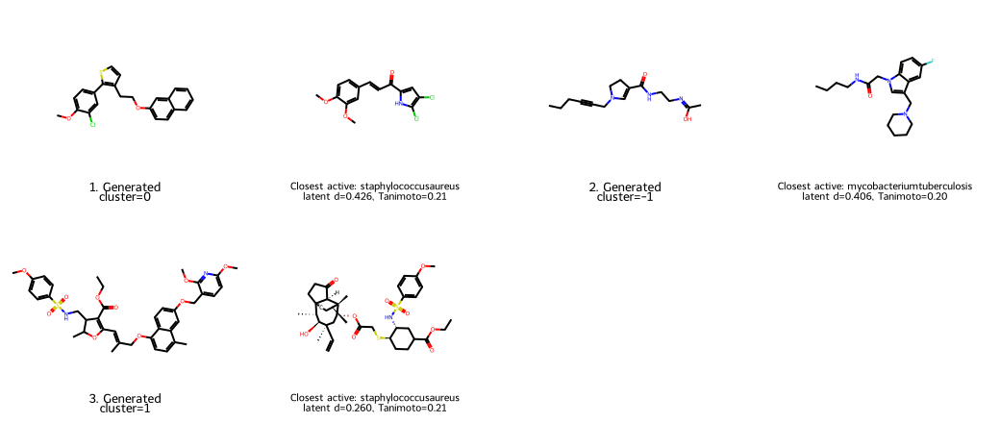

In [107]:
from rdkit.Chem import Draw

def mol_from_smiles_safe(smi):
    mol = Chem.MolFromSmiles(smi)
    return mol

pair_mols = []
pair_legends = []

for i, row in enumerate(selected_examples.itertuples(index=False), start=1):
    gen_mol = mol_from_smiles_safe(row.smiles)
    act_mol = mol_from_smiles_safe(row.neighbor_active_smiles)

    pair_mols.extend([gen_mol, act_mol])

    pair_legends.extend([
        f"{i}. Generated\ncluster={row.tsne_cluster}",
        f"Closest active: {row.neighbor_active_species}\n"
        f"latent d={row.neighbor_latent_cosine_distance:.3f}, "
        f"Tanimoto={row.tanimoto_to_top1_active:.2f}",
    ])

img_pairs = Draw.MolsToGridImage(
    pair_mols,
    molsPerRow=4,   # two pairs per row
    subImgSize=(260, 220),
    legends=pair_legends,
    useSVG=False,
)

img_pairs

In [89]:
region_candidates = mabs_tsne[
    mabs_tsne["tsne_1"].between(-75, -50)
    & mabs_tsne["tsne_2"].between(60, 80)
].copy()

print(f"Molecules in selected region: {len(region_candidates)}")

if region_candidates.empty:
    raise ValueError(
        "No M. abscessus-generated molecules found in the selected t-SNE region."
    )

# Centre of the selected rectangle
region_centre = np.array([-62.5, 70.0])

region_candidates["dist_to_region_centre"] = np.sqrt(
    (
        (
            region_candidates[["tsne_1", "tsne_2"]].to_numpy()
            - region_centre
        ) ** 2
    ).sum(axis=1)
)

# Prefer moderate structural similarity to the closest active
preferred_candidates = region_candidates[
    region_candidates["tanimoto_to_top1_active"].between(0.2, 0.8)
].copy()

if preferred_candidates.empty:
    preferred_candidates = region_candidates.copy()

region_pick = preferred_candidates.sort_values(
    [
        "dist_to_region_centre",
        "neighbor_latent_cosine_distance",
    ],
    ascending=[True, True],
).head(1)

region_pick[
    [
        "generated_id",
        "tsne_cluster",
        "tsne_1",
        "tsne_2",
        "neighbor_active_species",
        "neighbor_latent_cosine_distance",
        "tanimoto_to_top1_active",
    ]
]

Molecules in selected region: 1


,generated_id,tsne_cluster,tsne_1,tsne_2,neighbor_active_species,neighbor_latent_cosine_distance,tanimoto_to_top1_active
499,mycobacteroidesabscessus__499,-1,-61.893745,72.211739,mycobacteriumtuberculosis,0.420589,0.137255


In [111]:
isolated_picks_df

,generated_id,species_generated_for,smiles,local_generated_index,batch_number,query_group,set_name,active_smiles,active_species,active_pair_id,...,neighbor_active_smiles,neighbor_active_species,neighbor_latent_cosine_distance,neighbor_rank,tanimoto_to_top1_active,tsne_cluster,frac_mabs_actives_local,frac_related_actives_local,dist_to_cluster_centroid,species_already_used
0,mycobacteroidesabscessus__742,mycobacteroidesabscessus,CCOC(=O)C1=C(C=C(C)COc2ccc(C)c3cc(OCc4ccc(OC)n...,742.0,742.0,mabs_generated,mabs_generated,NaN,NaN,NaN,...,C=C[C@]1(C)C[C@@H](OC(=O)CS[C@@H]2CCC(C(=O)OCC...,staphylococcusaureus,0.259515,1,0.212766,1,0.0,0.0,1.551875,False


In [112]:
isolated_picks_df_updated = region_pick

In [113]:
selected_examples = pd.concat(
    [
        central_pick,
        mabs_active_region_pick,
        isolated_picks_df_updated,
    ],
    ignore_index=True,
)

selected_examples = (
    selected_examples
    .drop_duplicates("generated_id")
    .reset_index(drop=True)
)

In [114]:
isolated_picks_df_updated

,generated_id,species_generated_for,smiles,local_generated_index,batch_number,query_group,set_name,active_smiles,active_species,active_pair_id,...,tsne_2,neighbor_active_smiles,neighbor_active_species,neighbor_latent_cosine_distance,neighbor_rank,tanimoto_to_top1_active,tsne_cluster,frac_mabs_actives_local,frac_related_actives_local,dist_to_region_centre
499,mycobacteroidesabscessus__499,mycobacteroidesabscessus,Clc1ccc2c(c1)SCC2OCCC(Cc1cccnc1)N1CCc2ccccc2C1,499.0,499.0,mabs_generated,mabs_generated,NaN,NaN,NaN,...,72.211739,O=[N+]([O-])c1cn2c(n1)O[C@@H](CCOCc1ccc(-c3ccc...,mycobacteriumtuberculosis,0.420589,1,0.137255,-1,0.0,0.96,2.293323


In [124]:
selected_examples[['generated_id', 'smiles',
       'local_generated_index', 
       'active_smiles', 'active_species', 'active_pair_id',
       'unrelated_active_index', 'tsne_1', 'tsne_2', 'neighbor_active_smiles',
       'neighbor_active_species', 'neighbor_latent_cosine_distance',
       'neighbor_rank', 'tanimoto_to_top1_active', 'tsne_cluster',
       'dist_to_cluster_centroid', 'frac_mabs_actives_local',
       'frac_related_actives_local', 'dist_to_region_centre']]

,generated_id,smiles,local_generated_index,active_smiles,active_species,active_pair_id,unrelated_active_index,tsne_1,tsne_2,neighbor_active_smiles,neighbor_active_species,neighbor_latent_cosine_distance,neighbor_rank,tanimoto_to_top1_active,tsne_cluster,dist_to_cluster_centroid,frac_mabs_actives_local,frac_related_actives_local,dist_to_region_centre
0,mycobacteroidesabscessus__636,COc1ccc(-c2sccc2CCOc2ccc3ccccc3c2)cc1Cl,636.0,NaN,NaN,NaN,NaN,30.938150,42.801189,COc1ccc(/C=C/C(=O)c2cc(Cl)c(Cl)[nH]2)cc1OC,staphylococcusaureus,0.426250,1,0.211268,0,1.484166,NaN,NaN,NaN
1,mycobacteroidesabscessus__486,CCCC#CCN1C=C(C(=O)NCCN=C(C)O)CC1,486.0,NaN,NaN,NaN,NaN,32.323189,81.508301,CCCCNC(=O)Cn1cc(CN2CCCCC2)c2cc(F)ccc21,mycobacteriumtuberculosis,0.405909,1,0.200000,-1,NaN,0.4,0.52,NaN
2,mycobacteroidesabscessus__499,Clc1ccc2c(c1)SCC2OCCC(Cc1cccnc1)N1CCc2ccccc2C1,499.0,NaN,NaN,NaN,NaN,-61.893745,72.211739,O=[N+]([O-])c1cn2c(n1)O[C@@H](CCOCc1ccc(-c3ccc...,mycobacteriumtuberculosis,0.420589,1,0.137255,-1,NaN,0.0,0.96,2.293323


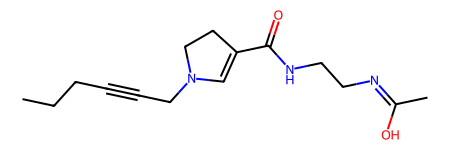

In [125]:
Chem.MolFromSmiles(selected_examples["smiles"].iloc[1])

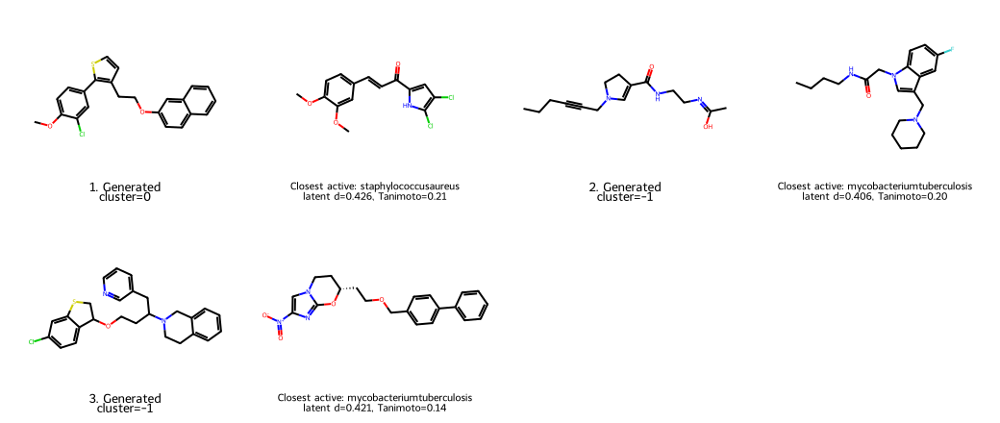

In [116]:
pair_mols = []
pair_legends = []

for i, row in enumerate(selected_examples.itertuples(index=False), start=1):
    gen_mol = mol_from_smiles_safe(row.smiles)
    act_mol = mol_from_smiles_safe(row.neighbor_active_smiles)

    pair_mols.extend([gen_mol, act_mol])

    pair_legends.extend([
        f"{i}. Generated\ncluster={row.tsne_cluster}",
        f"Closest active: {row.neighbor_active_species}\n"
        f"latent d={row.neighbor_latent_cosine_distance:.3f}, "
        f"Tanimoto={row.tanimoto_to_top1_active:.2f}",
    ])

img_pairs = Draw.MolsToGridImage(
    pair_mols,
    molsPerRow=4,   # two pairs per row
    subImgSize=(260, 220),
    legends=pair_legends,
    useSVG=False,
)

img_pairs

In [ ]:
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd

def mol_from_smiles_safe(smi):
    if pd.isna(smi):
        return None
    return Chem.MolFromSmiles(smi)

pair_outdir = "./"


for i, row in enumerate(selected_examples.itertuples(index=False), start=1):
    gen_mol = mol_from_smiles_safe(row.smiles)
    act_mol = mol_from_smiles_safe(row.neighbor_active_smiles)

    if gen_mol is None or act_mol is None:
        print(f"Skipping pair {i}: invalid molecule")
        continue

    pair_img = Draw.MolsToGridImage(
        [gen_mol, act_mol],
        molsPerRow=2,
        subImgSize=(500, 500),
        legends=["", ""],
        useSVG=False,
    )

    # Convert IPython display Image to PIL if needed
    if hasattr(pair_img, "save"):
        pair_img.save(pair_outdir + f"pair_{i}.png")
    elif hasattr(pair_img, "data"):
        with open(pair_outdir + f"pair_{i}.png", "wb") as f:
            f.write(pair_img.data)
    else:
        raise TypeError(f"Unknown image object type: {type(pair_img)}")

print(f"Saved images to: {pair_outdir}")

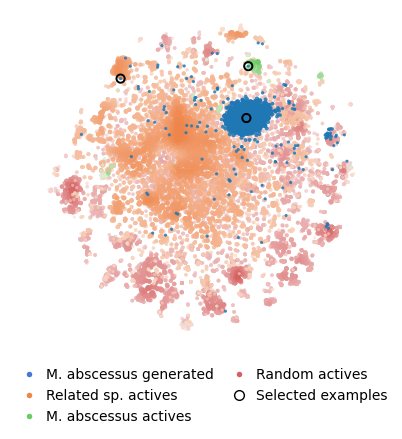

In [120]:
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.interpolate import interpn
from matplotlib.colors import to_hex, to_rgb

selected_examples = selected_examples.head(3)

def get_density_and_size(x, y, bins=20, min_size=5, max_size=10):
    """
    Estimate local 2D density and map density to marker size.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) == 0:
        return np.array([]), np.array([])

    data, x_e, y_e = np.histogram2d(x, y, bins=bins, density=True)

    x_centers = 0.5 * (x_e[1:] + x_e[:-1])
    y_centers = 0.5 * (y_e[1:] + y_e[:-1])

    z = interpn(
        (x_centers, y_centers),
        data,
        np.vstack([x, y]).T,
        method="linear",
        bounds_error=False,
        fill_value=0.0,
    )

    z[np.isnan(z)] = 0.0

    z_norm = (z - z.min()) / (z.max() - z.min() + 1e-9)
    sizes = min_size + z_norm * (max_size - min_size)

    return z, sizes


def make_light_to_color_cmap(name, color, light="#fbfbfb"):
    return mcolors.LinearSegmentedColormap.from_list(name, [light, color])


# Colors matching your current legend style
muted = sns.color_palette("muted")

COLORS = {
    "mabs_generated": muted[0],             # blue
    "related_species_actives": muted[1],    # orange
    "mabs_actives": muted[2],               # green
    "random_actives": muted[3],             # red
}

LABELS = {
    "mabs_generated": "M. abscessus generated",
    "related_species_actives": "Related sp. actives",
    "mabs_actives": "M. abscessus actives",
    "random_actives": "Random actives",
}

def lighten_color(color, amount=0.72):
    """
    Blend a colour with white.

    amount=0 keeps the original colour.
    amount=1 gives white.
    """
    rgb = np.array(to_rgb(color))
    return tuple(rgb + (1 - rgb) * amount)


LIGHT_COLORS = {
    key: lighten_color(color, amount=0.72)
    for key, color in COLORS.items()
}
def make_light_to_color_cmap(name, color):
    return mcolors.LinearSegmentedColormap.from_list(
        name,
        [LIGHT_COLORS[name], color]
    )

CMAPS = {
    key: make_light_to_color_cmap(key, color)
    for key, color in COLORS.items()
}

# Plot order: background first, generated last/on top
plot_order = [
    "random_actives",
    "related_species_actives",
    "mabs_actives",
    "mabs_generated",
]

fig, ax = plt.subplots(figsize=(4.5, 4.5))

percentage_to_plot = {
    "random_actives": 1.0,
    "related_species_actives": 1.0,
    "mabs_actives": 1.0,
    "mabs_generated": 1.0,
}

for set_name in plot_order:
    df_set = latent_tsne_meta[latent_tsne_meta["set_name"] == set_name].copy()

    if len(df_set) == 0:
        continue

    frac = percentage_to_plot.get(set_name, 1.0)

    if frac < 1.0:
        df_set = df_set.sample(
            n=max(1, int(len(df_set) * frac)),
            random_state=SEED,
        )

    x = df_set["tsne_1"].values
    y = df_set["tsne_2"].values

    z, sizes = get_density_and_size(
        x,
        y,
        bins=20,
        min_size=5,
        max_size=15 if set_name != "mabs_generated" else 20,
    )

    # Plot lower-density points first, denser points later
    idx = np.argsort(z)

    alpha = 0.55 if set_name != "mabs_generated" else 0.75
    zorder = 2 if set_name != "mabs_generated" else 5
    if set_name == "mabs_generated":
        ax.scatter(
            x[idx],
            y[idx],
            color="tab:blue",
            s=sizes[idx],
            alpha=0.85,
            linewidths=0,
            zorder=5,
        )
    else:
        ax.scatter(
            x[idx],
            y[idx],
            c=z[idx],
            s=sizes[idx],
            cmap=CMAPS[set_name],
            alpha=alpha,
            linewidths=0,
            zorder=zorder,
        )
    # ax.scatter(
    #     x[idx],
    #     y[idx],
    #     c=z[idx],
    #     s=sizes[idx],
    #     cmap=CMAPS[set_name],
    #     alpha=alpha,
    #     linewidths=0,
    #     zorder=zorder,
    # )

# Highlight selected examples on top
if "selected_examples" in globals() and selected_examples is not None:
    ax.scatter(
        selected_examples["tsne_1"],
        selected_examples["tsne_2"],
        s=35,
        facecolors="none",
        edgecolors="black",
        linewidths=1.4,
        zorder=10,
        label="Selected examples",
    )

# Remove axes for a clean figure style
ax.set_axis_off()
ax.set_box_aspect(1)

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=LABELS["mabs_generated"],
        markerfacecolor=COLORS["mabs_generated"],
        markersize=5,
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=LABELS["related_species_actives"],
        markerfacecolor=COLORS["related_species_actives"],
        markersize=5,
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=LABELS["mabs_actives"],
        markerfacecolor=COLORS["mabs_actives"],
        markersize=5,
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label=LABELS["random_actives"],
        markerfacecolor=COLORS["random_actives"],
        markersize=5,
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="black",
        label="Selected examples",
        markerfacecolor="none",
        markersize=7,
        linewidth=0,
    ),
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.03),
    ncol=2,
    frameon=False,
    handletextpad=0.2,
    columnspacing=0.8,
)

plt.tight_layout()


plt.show()